In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [ ]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/stations_msnumerical_vars_bearing.csv")
#weathercluster_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/weather_7.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
#Static_contr = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/static_contributers.csv")

stats_df["station"] = stats_df["station"].astype(int)
stats_df["lat"] = stats_df["coast_lat"]
stats_df["lon"] = stats_df["coast_lon"]
GEV_clusters["station"] = GEV_clusters["station"].astype(int)
GEV_clusters["cluster_id"] = GEV_clusters["cluster"]

GEV_clusters= GEV_clusters[~GEV_clusters["cluster"].isin([0, 5])].copy()
# Get sorted unique remaining clusters
unique_clusters = sorted( GEV_clusters["cluster"].unique())
# Build mapping → start numbering from 1
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}
# Apply remapping
GEV_clusters["cluster"] =  GEV_clusters["cluster"].map(cluster_map)

label_df = GEV_clusters[["station", "cluster", "cluster_id", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on=["station", "lat", "lon"], how="inner")
#model_df = model_df.merge(Static_contr, on=["station","lat", "lon", "cluster"], how="inner")

In [181]:
stats_df_test = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/all_numerical_vars_bearing.csv")

In [187]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "status", "H", "id", "ID", "HYR", "GEOM", "POINT")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in stats_df_test.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
#model_df = model_df.groupby("station").mean(numeric_only=True)
#model_df = model_df.reset_index().groupby("station").agg(
 #   lambda x: x.max() if pd.api.types.is_numeric_dtype(x)
 #   else x.mode().iloc[0]
#)
# Compute cluster sizes
#cluster_counts = stats_df_test ["cluster_id"].value_counts()

# Keep only stations belonging to clusters with >1 entry
#model_df = model_df[model_df["cluster_id"].isin(cluster_counts[cluster_counts > 1].index)]
# Build feature matrix
X_coastline = stats_df_test .drop(columns=[c for c in cols_to_drop if c in stats_df_test .columns])

In [183]:
print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level","residual","tide","lat","lon","count","missing_frac",
                        "extract_time","name","unnamed", "name", "Unnamed", 'HYRIV' , "gev", "ks", "kuiper", "r2", "dist_to_CVI_m",
                        "dist_to_morpho_m", "status", "H", "id", "ID", "HYR", "GEOM", "POINT")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols
#model_df = model_df.groupby("station").mean(numeric_only=True)
#model_df = model_df.reset_index().groupby("station").agg(
 #   lambda x: x.max() if pd.api.types.is_numeric_dtype(x)
 #   else x.mode().iloc[0]
#)
# Compute cluster sizes
cluster_counts = model_df["cluster_id"].value_counts()

# Keep only stations belonging to clusters with >1 entry
model_df = model_df[model_df["cluster_id"].isin(cluster_counts[cluster_counts > 1].index)]
# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster_id']

Stations for modeling: 277
cluster
3    97
1    78
4    70
5    16
2    16
Name: count, dtype: int64


In [184]:
X = X.select_dtypes(include='number')

In [188]:
forbidden_2 = forbidden_cols | {"station"}
X_coastline = stats_df_test.drop(columns=[c for c in forbidden_2  if c in model_df.columns])

In [189]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# keep only numeric columns
X = X.select_dtypes(include=[np.number]).copy()

# replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# drop columns that are all NaN
X = X.dropna(axis=1, how='all')

# fill remaining NaNs with column means
X = X.fillna(X.mean())
# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [196]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split

# Train/test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

pipe = Pipeline([
    ("smote", SMOTE(random_state=0)),
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=0, n_jobs=-1))
])

param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "rf__n_estimators": [300, 500, 800, 1200],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", 0.5],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
   # scoring="f1_weighted",   # or "precision_weighted", "balanced_accuracy", etc.
    scoring="precision_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=0,
    refit=True
)

search.fit(X_train, y_train)

print("Best params:")
print(search.best_params_)
print("Best CV score:", search.best_score_)

best_model = search.best_estimator_
pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

Best params:
{'smote__k_neighbors': 5, 'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'rf__max_depth': 20, 'rf__class_weight': None}
Best CV score: 0.7636274692946142
Test accuracy: 0.8
              precision    recall  f1-score   support

           1       0.84      0.80      0.82        20
           2       0.67      0.50      0.57         4
           3       0.85      0.92      0.88        24
           4       0.72      0.72      0.72        18
           6       0.75      0.75      0.75         4

    accuracy                           0.80        70
   macro avg       0.77      0.74      0.75        70
weighted avg       0.80      0.80      0.80        70



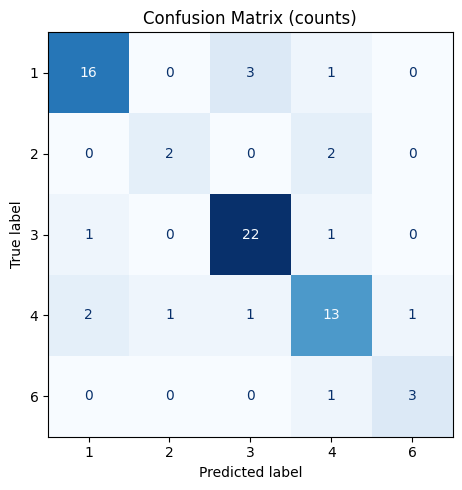

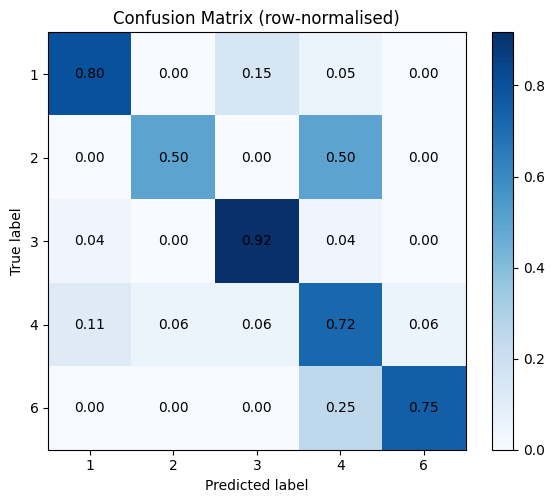

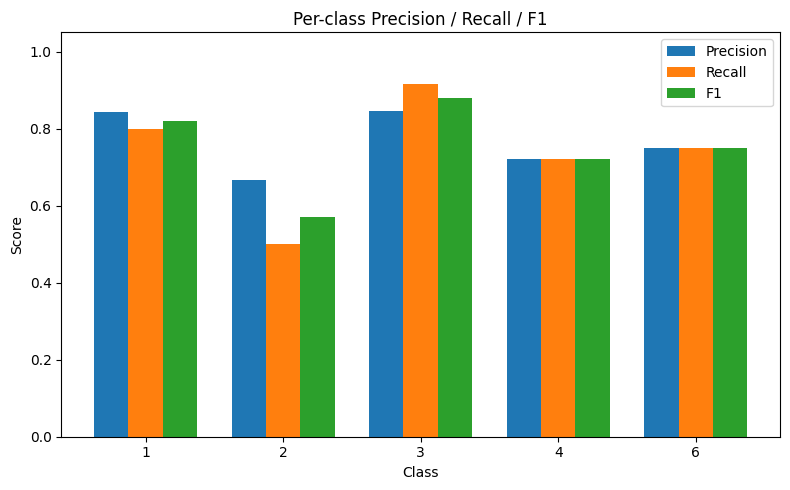

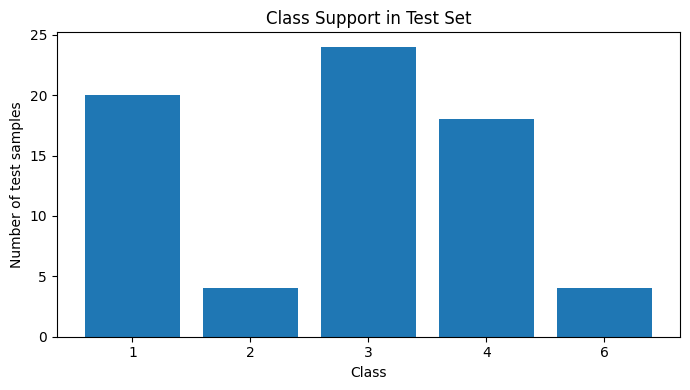

Top confusion pairs:
   true_class  pred_class  count
0           1           3      3
1           2           4      2
2           4           1      2
3           1           4      1
4           3           1      1
5           3           4      1
6           4           2      1
7           4           3      1
8           4           6      1
9           6           4      1


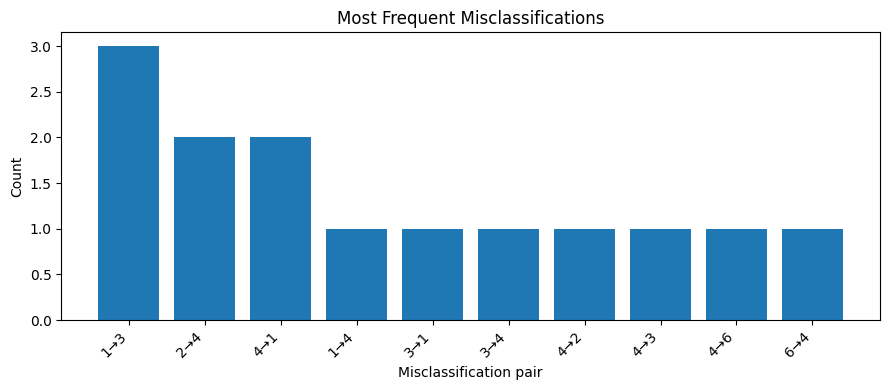

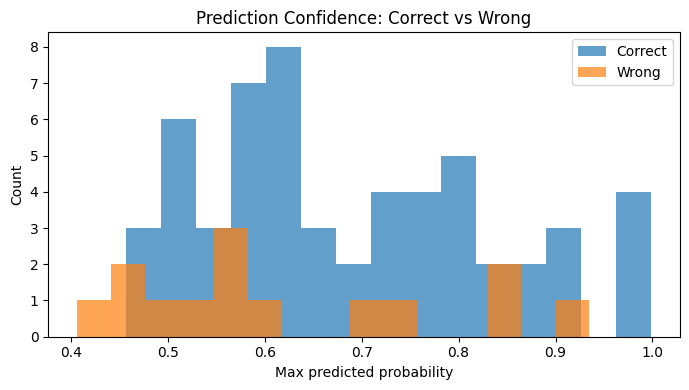


Lowest-confidence predictions:
     y_true  y_pred  confidence  correct
261       1       3    0.406198    False
203       1       1    0.456958     True
222       2       4    0.459804    False
208       1       1    0.464115     True
50        1       1    0.470327     True
167       4       1    0.470521    False
104       4       4    0.497045     True
90        4       3    0.508437    False
164       1       3    0.513750    False
78        4       4    0.516250     True
45        3       3    0.516435     True
75        3       3    0.517188     True
161       3       3    0.520000     True
87        3       3    0.527917     True
144       1       1    0.529777     True

Classification report:
              precision    recall  f1-score  support
1              0.842105  0.800000  0.820513     20.0
2              0.666667  0.500000  0.571429      4.0
3              0.846154  0.916667  0.880000     24.0
4              0.722222  0.722222  0.722222     18.0
6              0.750000

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support
)

# ---- predictions ----
pred = best_model.predict(X_test)

# class labels in sorted order
labels = np.sort(np.unique(y_test))

# -----------------------------
# 1) Raw confusion matrix
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    labels=labels,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix (counts)")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Row-normalized confusion matrix
#    (recall-oriented: how each true class gets distributed)
# -----------------------------
cm = confusion_matrix(y_test, pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix (row-normalised)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Per-class metrics bar chart
# -----------------------------
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, pred, labels=labels, zero_division=0
)

metrics_df = pd.DataFrame({
    "class": labels,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": support
})

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, metrics_df["precision"], width=w, label="Precision")
ax.bar(x,     metrics_df["recall"],    width=w, label="Recall")
ax.bar(x + w, metrics_df["f1"],        width=w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["class"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_title("Per-class Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Support by class
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metrics_df["class"].astype(str), metrics_df["support"])
ax.set_xlabel("Class")
ax.set_ylabel("Number of test samples")
ax.set_title("Class Support in Test Set")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Top confusion pairs
# -----------------------------
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i, true_cls in enumerate(labels):
    for j, pred_cls in enumerate(labels):
        if i != j and cm_offdiag[i, j] > 0:
            pairs.append((true_cls, pred_cls, cm_offdiag[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
pairs_df = pd.DataFrame(pairs, columns=["true_class", "pred_class", "count"])

print("Top confusion pairs:")
print(pairs_df.head(10))

# Plot top confusion pairs
top_n = min(10, len(pairs_df))
if top_n > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    labels_pairs = [f"{t}→{p}" for t, p in zip(pairs_df["true_class"][:top_n], pairs_df["pred_class"][:top_n])]
    ax.bar(labels_pairs, pairs_df["count"][:top_n])
    ax.set_xlabel("Misclassification pair")
    ax.set_ylabel("Count")
    ax.set_title("Most Frequent Misclassifications")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6) Prediction confidence analysis
#    (requires predict_proba)
# -----------------------------
if hasattr(rf, "predict_proba"):
    proba = rf.predict_proba(X_test_scaled)
    max_proba = proba.max(axis=1)

    correct = (pred == y_test)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(max_proba[correct], bins=15, alpha=0.7, label="Correct")
    ax.hist(max_proba[~correct], bins=15, alpha=0.7, label="Wrong")
    ax.set_xlabel("Max predicted probability")
    ax.set_ylabel("Count")
    ax.set_title("Prediction Confidence: Correct vs Wrong")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Lowest-confidence predictions
    err_df = pd.DataFrame({
        "y_true": y_test,
        "y_pred": pred,
        "confidence": max_proba,
        "correct": correct
    }).sort_values("confidence")

    print("\nLowest-confidence predictions:")
    print(err_df.head(15))

# -----------------------------
# 7) Classification report table
# -----------------------------
report_df = pd.DataFrame(
    classification_report(y_test, pred, output_dict=True, zero_division=0)
).T
print("\nClassification report:")
print(report_df)

In [199]:
status_cols = [c for c in X_coastline.columns if "status" in c]
# keep only numeric columns
X_coastline = X_coastline.select_dtypes(include=[np.number]).copy()
X_coastline = X_coastline.replace([np.inf, -np.inf], np.nan)
X_coastline = X_coastline.dropna(axis=1, how='all')
X_coastline = X_coastline.fillna(X.mean())

X_coastline_scaled= scaler.transform(X_coastline)
#pred_coastline = rf.predict(X_coastline_scaled)

#pred_coastline =rf.predict(X_coastline_scaled)
pred_coastline = best_model.predict(X_coastline_scaled)
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


IndexError: list index out of range

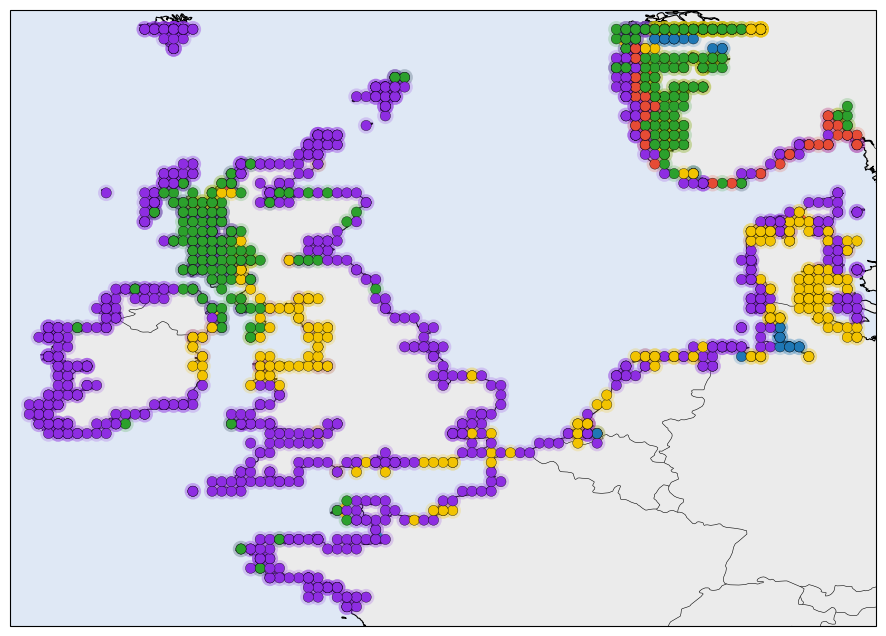

In [200]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- setup ---
cluster_col = "pred_cluster"
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()
plot_df[cluster_col] = plot_df[cluster_col].astype(int)

clusters = np.sort(plot_df[cluster_col].unique())
n_clusters = len(clusters)

base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red
]
colors = base_colors[:n_clusters]
cmap = mcolors.ListedColormap(colors)

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="0.92")
ax.add_feature(cfeature.OCEAN, facecolor="#dfe8f5")
ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

ax.set_extent([
    plot_df["lon"].min() - 0.5,
    plot_df["lon"].max() + 0.5,
    plot_df["lat"].min() - 0.5,
    plot_df["lat"].max() + 0.5
], crs=ccrs.PlateCarree())

# --- soft halo underneath ---
ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=140,
    alpha=0.20,
    cmap=cmap,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# --- main points ---
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=55,
    cmap=cmap,
    edgecolor="k",
    linewidth=0.25,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# --- optional: connect only short local segments within each cluster ---
# This avoids long bogus coast-crossing lines.
for cluster in clusters:
    subset = plot_df.loc[plot_df[cluster_col] == cluster, ["lon", "lat"]].copy()

    coords = subset[["lon", "lat"]].to_numpy()
    if len(coords) < 2:
        continue

    # naive local linking: sort by latitude then longitude as a rough path
    subset = subset.sort_values(["lat", "lon"]).reset_index(drop=True)

    # only draw segment if adjacent points are close enough
    max_dist = 0.4  # tune to your station spacing
    for i in range(len(subset) - 1):
        x1, y1 = subset.loc[i, ["lon", "lat"]]
        x2, y2 = subset.loc[i + 1, ["lon", "lat"]]
        dist = np.hypot(x2 - x1, y2 - y1)

        if dist <= max_dist:
            ax.plot(
                [x1, x2], [y1, y2],
                color=colors[int(cluster)],
                linewidth=2.0,
                alpha=0.8,
                transform=ccrs.PlateCarree(),
                zorder=2.5
            )

# --- legend instead of only colorbar ---
handles = [
    mpatches.Patch(color=colors[i], label=f"Cluster {clusters[i]}")
    for i in range(n_clusters)
]
ax.legend(handles=handles, loc="lower left", title="Regime", frameon=True)

plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03, label=cluster_col)
plt.title("Predicted coastal surge regimes")
plt.show()

# protect at all costs

In [168]:
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
X_train, y_train = SMOTE().fit_resample(X_train, y_train)

# Scale using TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA using TRAIN only
pca = PCA(n_components=20, random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf = RandomForestClassifier(
    n_estimators=800,
    random_state=0,
    n_jobs=-1,
    #class_weight="balanced"
)
rf.fit(X_train_scaled, y_train)
pred = rf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, X, y, cv=5, scoring='precision_weighted')
print(scores, scores.mean())

Accuracy: 0.8
              precision    recall  f1-score   support

           1       0.84      0.80      0.82        20
           2       0.67      0.50      0.57         4
           3       0.81      0.92      0.86        24
           4       0.76      0.72      0.74        18
           6       0.75      0.75      0.75         4

    accuracy                           0.80        70
   macro avg       0.77      0.74      0.75        70
weighted avg       0.80      0.80      0.80        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[0.37957317 0.77117674 0.63602912 0.65925545 0.67505051] 0.6242169977067265


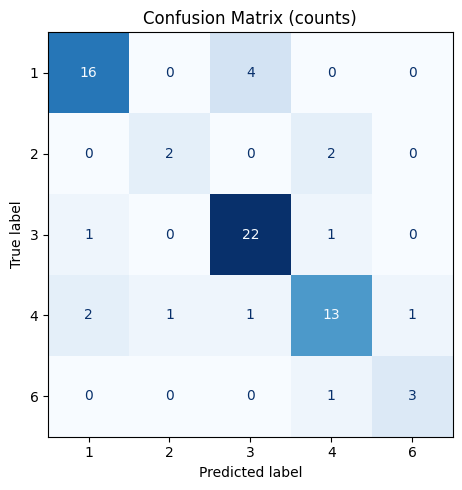

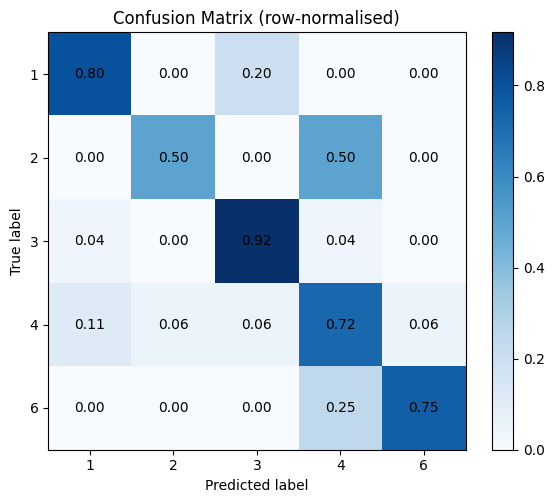

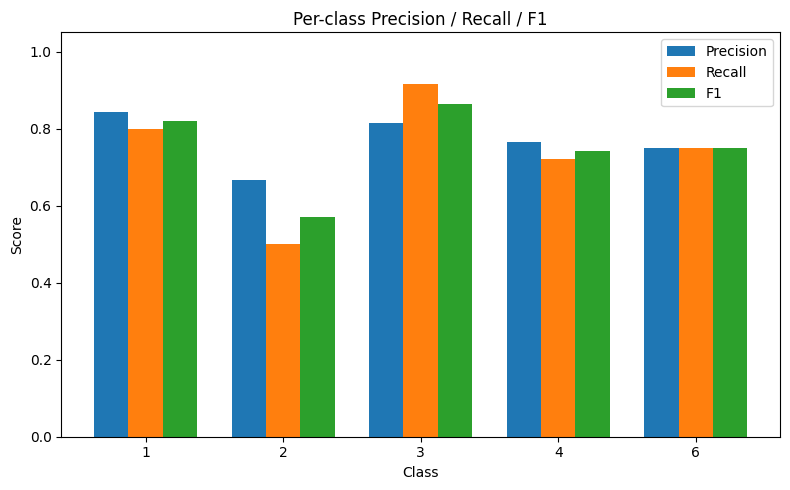

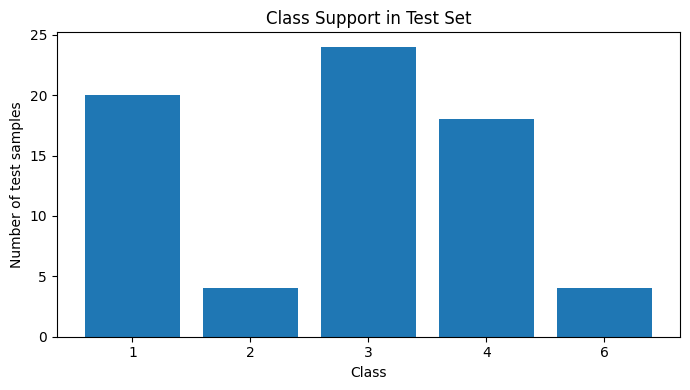

Top confusion pairs:
   true_class  pred_class  count
0           1           3      4
1           2           4      2
2           4           1      2
3           3           1      1
4           3           4      1
5           4           2      1
6           4           3      1
7           4           6      1
8           6           4      1


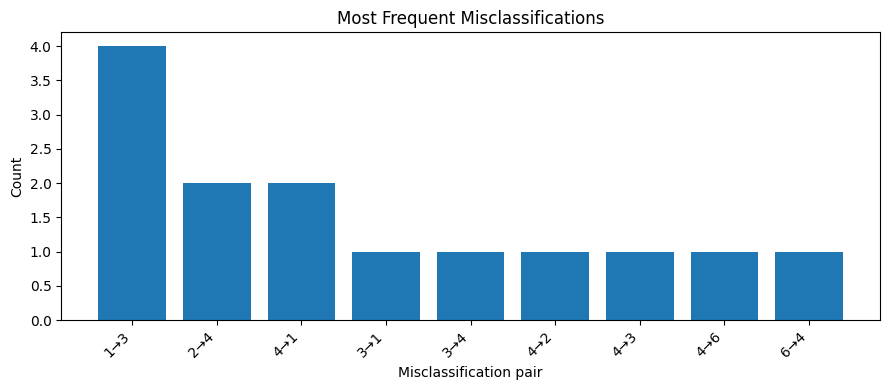

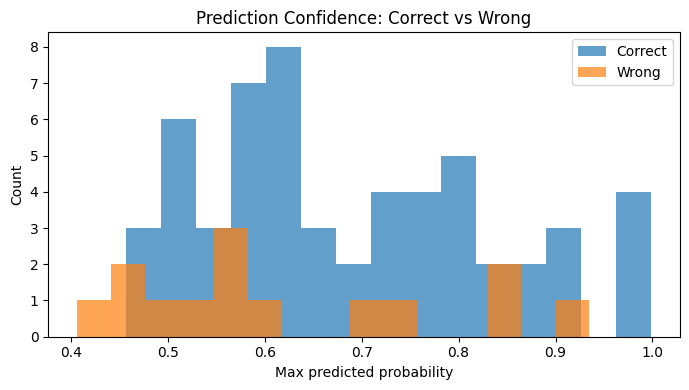


Lowest-confidence predictions:
     y_true  y_pred  confidence  correct
261       1       3    0.406198    False
203       1       1    0.456958     True
222       2       4    0.459804    False
208       1       1    0.464115     True
50        1       1    0.470327     True
167       4       1    0.470521    False
104       4       4    0.497045     True
90        4       3    0.508437    False
164       1       3    0.513750    False
78        4       4    0.516250     True
45        3       3    0.516435     True
75        3       3    0.517188     True
161       3       3    0.520000     True
87        3       3    0.527917     True
144       1       1    0.529777     True

Classification report:
              precision    recall  f1-score  support
1              0.842105  0.800000  0.820513     20.0
2              0.666667  0.500000  0.571429      4.0
3              0.814815  0.916667  0.862745     24.0
4              0.764706  0.722222  0.742857     18.0
6              0.750000

In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support
)

# ---- predictions ----
pred = rf.predict(X_test_scaled)

# class labels in sorted order
labels = np.sort(np.unique(y_test))

# -----------------------------
# 1) Raw confusion matrix
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred,
    labels=labels,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix (counts)")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Row-normalized confusion matrix
#    (recall-oriented: how each true class gets distributed)
# -----------------------------
cm = confusion_matrix(y_test, pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix (row-normalised)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        val = cm_norm[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Per-class metrics bar chart
# -----------------------------
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, pred, labels=labels, zero_division=0
)

metrics_df = pd.DataFrame({
    "class": labels,
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "support": support
})

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, metrics_df["precision"], width=w, label="Precision")
ax.bar(x,     metrics_df["recall"],    width=w, label="Recall")
ax.bar(x + w, metrics_df["f1"],        width=w, label="F1")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["class"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_title("Per-class Precision / Recall / F1")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Support by class
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(metrics_df["class"].astype(str), metrics_df["support"])
ax.set_xlabel("Class")
ax.set_ylabel("Number of test samples")
ax.set_title("Class Support in Test Set")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Top confusion pairs
# -----------------------------
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i, true_cls in enumerate(labels):
    for j, pred_cls in enumerate(labels):
        if i != j and cm_offdiag[i, j] > 0:
            pairs.append((true_cls, pred_cls, cm_offdiag[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
pairs_df = pd.DataFrame(pairs, columns=["true_class", "pred_class", "count"])

print("Top confusion pairs:")
print(pairs_df.head(10))

# Plot top confusion pairs
top_n = min(10, len(pairs_df))
if top_n > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    labels_pairs = [f"{t}→{p}" for t, p in zip(pairs_df["true_class"][:top_n], pairs_df["pred_class"][:top_n])]
    ax.bar(labels_pairs, pairs_df["count"][:top_n])
    ax.set_xlabel("Misclassification pair")
    ax.set_ylabel("Count")
    ax.set_title("Most Frequent Misclassifications")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 6) Prediction confidence analysis
#    (requires predict_proba)
# -----------------------------
if hasattr(rf, "predict_proba"):
    proba = rf.predict_proba(X_test_scaled)
    max_proba = proba.max(axis=1)

    correct = (pred == y_test)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(max_proba[correct], bins=15, alpha=0.7, label="Correct")
    ax.hist(max_proba[~correct], bins=15, alpha=0.7, label="Wrong")
    ax.set_xlabel("Max predicted probability")
    ax.set_ylabel("Count")
    ax.set_title("Prediction Confidence: Correct vs Wrong")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Lowest-confidence predictions
    err_df = pd.DataFrame({
        "y_true": y_test,
        "y_pred": pred,
        "confidence": max_proba,
        "correct": correct
    }).sort_values("confidence")

    print("\nLowest-confidence predictions:")
    print(err_df.head(15))

# -----------------------------
# 7) Classification report table
# -----------------------------
report_df = pd.DataFrame(
    classification_report(y_test, pred, output_dict=True, zero_division=0)
).T
print("\nClassification report:")
print(report_df)

In [170]:
import pandas as pd

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
print(feat_imp.sort_values(ascending=False).head(15))

t2m_am_std               0.037445
wsk_am_std               0.022599
sst_am_std               0.022445
mwp_am_max               0.018927
t2m_am_max               0.017967
mwp_am_mean              0.016442
mwd_am_std               0.015979
wind_wave_diff_am_std    0.015338
sst_am_max               0.014923
curvature_mean_10x10     0.013691
swh_am_mean              0.013430
sp_am_std                0.013151
bearing_deg_3x3          0.013039
mwp_am_std               0.011957
msl_am_std               0.011911
dtype: float64


# Apply

In [201]:
status_cols = [c for c in X_coastline.columns if "status" in c]
# keep only numeric columns
X_coastline = X_coastline.select_dtypes(include=[np.number]).copy()
X_coastline = X_coastline.replace([np.inf, -np.inf], np.nan)
X_coastline = X_coastline.dropna(axis=1, how='all')
X_coastline = X_coastline.fillna(X.mean())

X_coastline_scaled= scaler.transform(X_coastline)
#pred_coastline = rf.predict(X_coastline_scaled)
pred_coastline = rf.predict(X_coastline_scaled)

In [202]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, pred)

for i, cls in enumerate(np.unique(y_test)):
    print(f"Class {cls}: Precision={precision[i]:.3f}, Recall={recall[i]:.3f}, F1={f1[i]:.3f}, Support={support[i]}")

Class 1: Precision=0.842, Recall=0.800, F1=0.821, Support=20
Class 2: Precision=0.667, Recall=0.500, F1=0.571, Support=4
Class 3: Precision=0.846, Recall=0.917, F1=0.880, Support=24
Class 4: Precision=0.722, Recall=0.722, F1=0.722, Support=18
Class 6: Precision=0.750, Recall=0.750, F1=0.750, Support=4


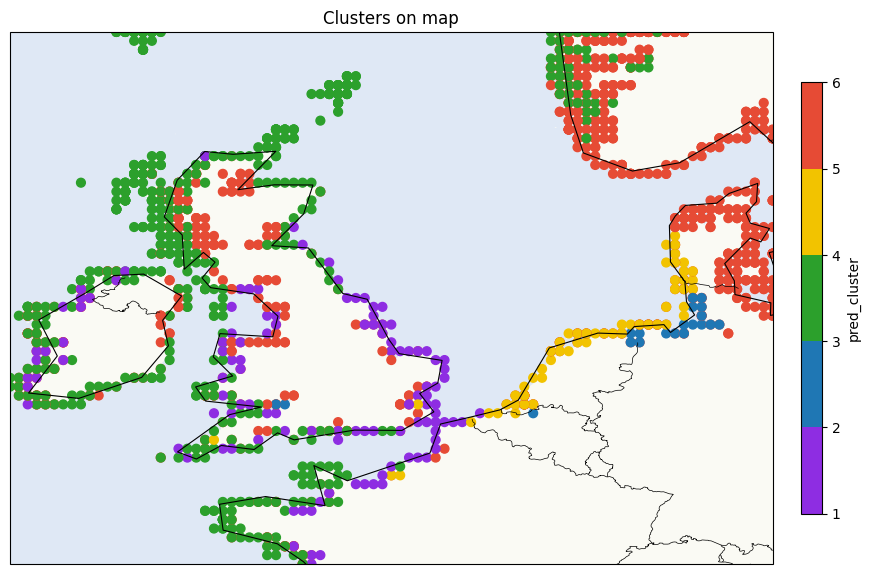

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

X_coastline_scaled= scaler.transform(X_coastline)
#pred_coastline = rf.predict(X_coastline_scaled)
pred_coastline = rf.predict(X_coastline_scaled)
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Merge back into stats_df
# Option 1: by index (best if stats_df_test came directly from stats_df and index was preserved)
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Pick cluster column to color by
cluster_col = "pred_cluster"   # or use an existing cluster column like "cluster_id"

# Keep only rows that have coordinates and cluster values
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()

# Plot
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ensure clusters are integers and sorted
clusters = np.sort(plot_df[cluster_col].unique())
n_clusters = len(clusters)
base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red (NEW)
]
colors = base_colors[:n_clusters]

cmap = mcolors.ListedColormap(colors)

ax.set_global()  # or set_extent([...]) for a regional map
ax.coastlines(resolution="110m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

ax.set_extent([stats_df_test_pred.lon.min(),stats_df_test_pred.lon.max(),stats_df_test_pred.lat.min(), stats_df_test_pred.lat.max()] )

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=40,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03, label=cluster_col)
plt.title("Clusters on map")
plt.show()

# Try improve

In [205]:
from imblearn.over_sampling import SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
X_train, y_train = SMOTE().fit_resample(X_train, y_train)

# Scale using TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA using TRAIN only
pca = PCA(n_components=20, random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

rf2 = RandomForestClassifier(
    n_estimators=1000,
    random_state=0,
    n_jobs=-1,
    class_weight="balanced",
)
rf2.fit(X_train_scaled, y_train)
pred = rf2.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf2, X, y, cv=5, scoring='balanced_accuracy')
print(scores, scores.mean())

Accuracy: 0.8428571428571429
              precision    recall  f1-score   support

           1       0.86      0.90      0.88        20
           2       0.75      0.75      0.75         4
           3       0.88      0.92      0.90        24
           4       0.81      0.72      0.76        18
           6       0.75      0.75      0.75         4

    accuracy                           0.84        70
   macro avg       0.81      0.81      0.81        70
weighted avg       0.84      0.84      0.84        70

[0.33190476 0.70666667 0.53458647 0.62177318 0.61096491] 0.5611791979949874


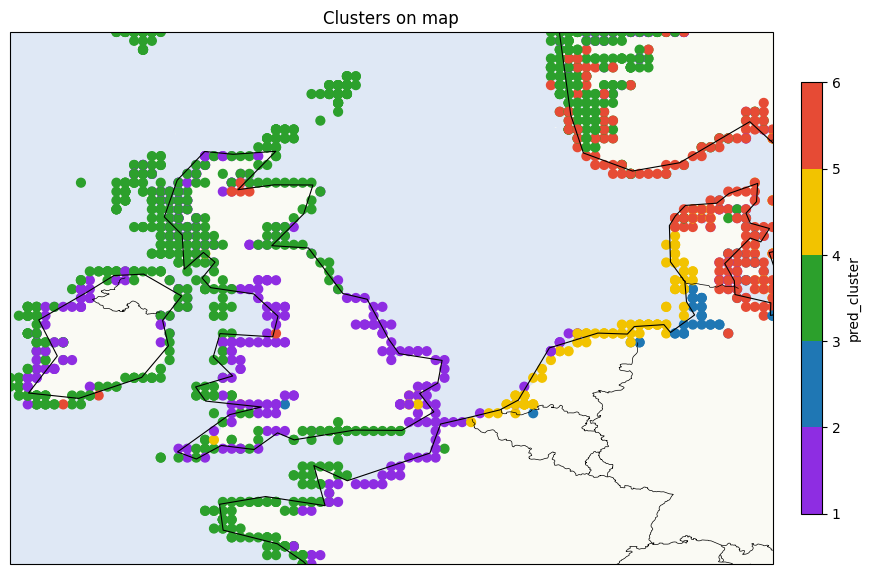

In [206]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

X_coastline_scaled= scaler.transform(X_coastline)
#pred_coastline = rf.predict(X_coastline_scaled)
pred_coastline = rf2.predict(X_coastline_scaled)
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Merge back into stats_df
# Option 1: by index (best if stats_df_test came directly from stats_df and index was preserved)
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Pick cluster column to color by
cluster_col = "pred_cluster"   # or use an existing cluster column like "cluster_id"

# Keep only rows that have coordinates and cluster values
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()

# Plot
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ensure clusters are integers and sorted
clusters = np.sort(plot_df[cluster_col].unique())
n_clusters = len(clusters)
base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red (NEW)
]
colors = base_colors[:n_clusters]

cmap = mcolors.ListedColormap(colors)

ax.set_global()  # or set_extent([...]) for a regional map
ax.coastlines(resolution="110m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

ax.set_extent([stats_df_test_pred.lon.min(),stats_df_test_pred.lon.max(),stats_df_test_pred.lat.min(), stats_df_test_pred.lat.max()] )

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=40,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03, label=cluster_col)
plt.title("Clusters on map")
plt.show()

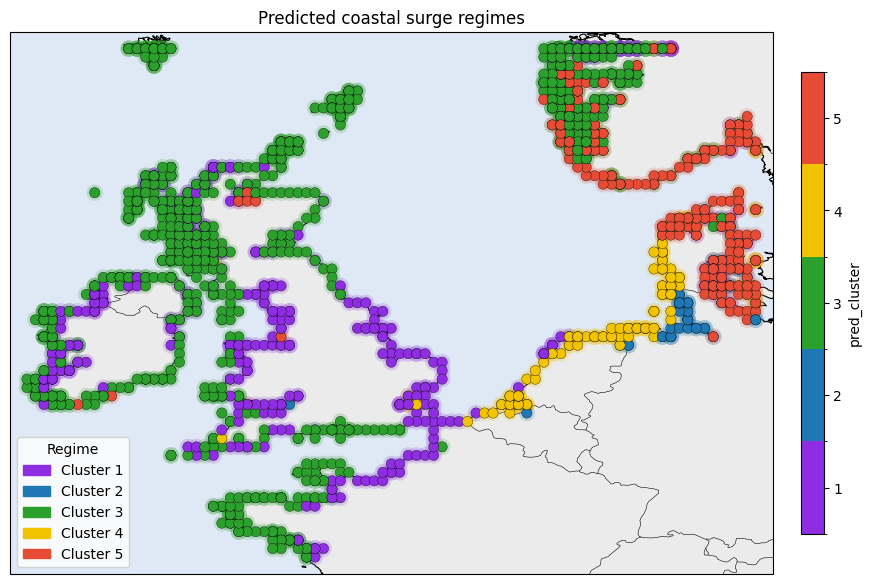

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

cluster_col = "pred_cluster"
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()
plot_df[cluster_col] = plot_df[cluster_col].astype(int).replace({6: 5})

clusters = np.array([1, 2, 3, 4, 5])
n_clusters = len(clusters)

base_colors = [
    "#8E2DE2",  # 1 purple
    "#1F77B4",  # 2 blue
    "#2CA02C",  # 3 green
    "#F2C300",  # 4 yellow
    "#E64B35",  # 5 orange-red
]
colors = base_colors[:n_clusters]
cmap = mcolors.ListedColormap(colors)

# discrete bins centered on 1,2,3,4,5
bounds = np.arange(0.5, 5.6, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="0.92")
ax.add_feature(cfeature.OCEAN, facecolor="#dfe8f5")
ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

ax.set_extent([
    plot_df["lon"].min() - 0.5,
    plot_df["lon"].max() + 0.5,
    plot_df["lat"].min() - 0.5,
    plot_df["lat"].max() + 0.5
], crs=ccrs.PlateCarree())

# soft halo
ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=140,
    alpha=0.20,
    cmap=cmap,
    norm=norm,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# main points
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=55,
    cmap=cmap,
    norm=norm,
    edgecolor="k",
    linewidth=0.25,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# short local segments
for cluster in clusters:
    subset = plot_df.loc[plot_df[cluster_col] == cluster, ["lon", "lat"]].copy()
    if len(subset) < 2:
        continue

    subset = subset.sort_values(["lat", "lon"]).reset_index(drop=True)

    max_dist = 0.4
    for i in range(len(subset) - 1):
        x1, y1 = subset.loc[i, ["lon", "lat"]]
        x2, y2 = subset.loc[i + 1, ["lon", "lat"]]
        dist = np.hypot(x2 - x1, y2 - y1)

        if dist <= max_dist:
            ax.plot(
                [x1, x2], [y1, y2],
                color=colors[cluster - 1],   # <- fixed
                linewidth=2.0,
                alpha=0.8,
                transform=ccrs.PlateCarree(),
                zorder=2.5
            )

handles = [
    mpatches.Patch(color=colors[i], label=f"Cluster {i+1}")
    for i in range(n_clusters)
]
ax.legend(handles=handles, loc="lower left", title="Regime", frameon=True)

cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label(cluster_col)
cbar.set_ticks(clusters)
cbar.set_ticklabels(clusters)

plt.title("Predicted coastal surge regimes")
plt.show()

# Model A: no SMOTE

In [155]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([
    ("rf", RandomForestClassifier(random_state=0, n_jobs=-1))
])

param_dist = {
    "rf__n_estimators": [300, 500, 800, 1200],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", 0.5],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=0,
    refit=True
)

search.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

pred = search.best_estimator_.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'rf__n_estimators': 800, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'rf__max_depth': 20, 'rf__class_weight': 'balanced_subsample'}
0.7589346761688102
Test accuracy: 0.7857142857142857
              precision    recall  f1-score   support

           1       0.84      0.80      0.82        20
           2       0.50      0.25      0.33         4
           3       0.85      0.92      0.88        24
           4       0.68      0.72      0.70        18
           6       0.75      0.75      0.75         4

    accuracy                           0.79        70
   macro avg       0.72      0.69      0.70        70
weighted avg       0.78      0.79      0.78        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


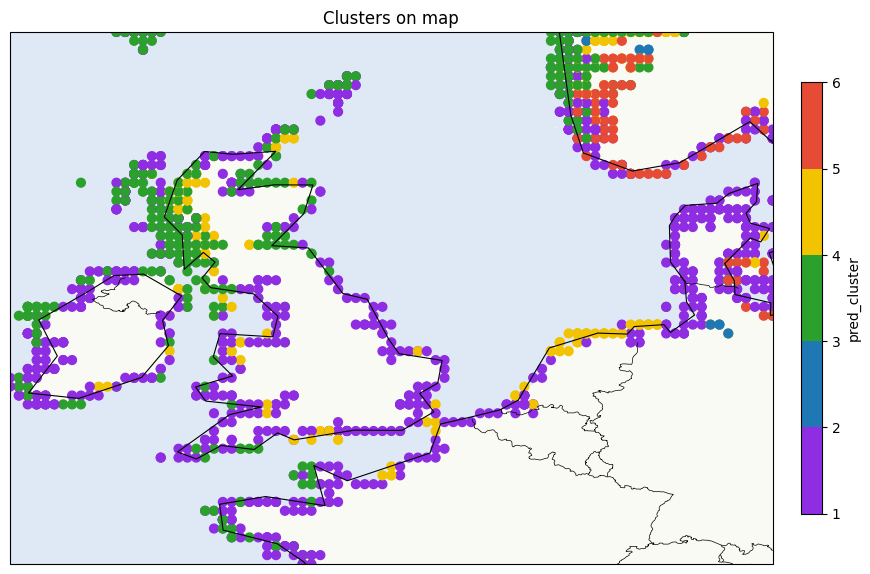

In [156]:
pred_coastline = search.best_estimator_.predict(X_coastline_scaled)

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Merge back into stats_df
# Option 1: by index (best if stats_df_test came directly from stats_df and index was preserved)
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Pick cluster column to color by
cluster_col = "pred_cluster"   # or use an existing cluster column like "cluster_id"

# Keep only rows that have coordinates and cluster values
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()

# Plot
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ensure clusters are integers and sorted
clusters = np.sort(plot_df[cluster_col].unique())
n_clusters = len(clusters)
base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red (NEW)
]
colors = base_colors[:n_clusters]

cmap = mcolors.ListedColormap(colors)

ax.set_global()  # or set_extent([...]) for a regional map
ax.coastlines(resolution="110m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

ax.set_extent([stats_df_test_pred.lon.min(),stats_df_test_pred.lon.max(),stats_df_test_pred.lat.min(), stats_df_test_pred.lat.max()] )

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=40,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03, label=cluster_col)
plt.title("Clusters on map")
plt.show()

# Model B: SMOTE but no scaler

In [166]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pipe = Pipeline([
    ("smote", SMOTE(random_state=1)),
    ("rf", RandomForestClassifier(random_state=0, n_jobs=-1))
])

param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "rf__n_estimators": [300, 500, 800, 1200],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2", 0.5],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

search_smoth = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="balanced_accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=0,
    refit=True
)

search_smoth.fit(X_train, y_train)
print(search.best_params_)
print(search.best_score_)

pred = search_smoth.best_estimator_.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
{'rf__n_estimators': 800, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 0.5, 'rf__max_depth': 20, 'rf__class_weight': 'balanced_subsample'}
0.7589346761688102
Test accuracy: 0.7428571428571429
              precision    recall  f1-score   support

           1       0.75      0.75      0.75        20
           2       0.50      0.50      0.50         4
           3       0.81      0.92      0.86        24
           4       0.67      0.56      0.61        18
           6       0.75      0.75      0.75         4

    accuracy                           0.74        70
   macro avg       0.70      0.69      0.69        70
weighted avg       0.74      0.74      0.74        70



/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


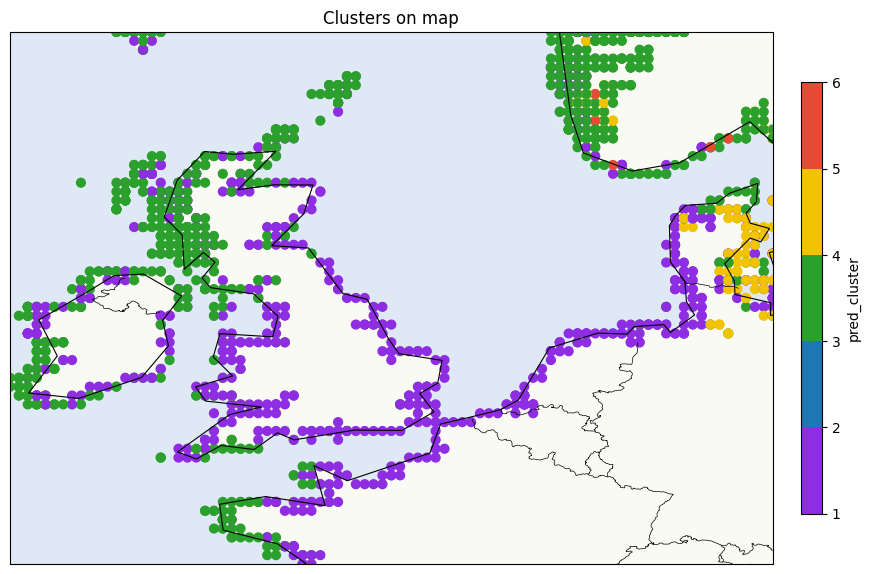

In [167]:
pred_coastline = search_smoth.best_estimator_.predict(X_coastline_scaled)

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Merge back into stats_df
# Option 1: by index (best if stats_df_test came directly from stats_df and index was preserved)
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Pick cluster column to color by
cluster_col = "pred_cluster"   # or use an existing cluster column like "cluster_id"

# Keep only rows that have coordinates and cluster values
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()

# Plot
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Ensure clusters are integers and sorted
clusters = np.sort(plot_df[cluster_col].unique())
n_clusters = 5
base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red (NEW)
]
colors = base_colors[:n_clusters]

cmap = mcolors.ListedColormap(colors)

ax.set_global()  # or set_extent([...]) for a regional map
ax.coastlines(resolution="110m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.OCEAN, alpha=0.3)

ax.set_extent([stats_df_test_pred.lon.min(),stats_df_test_pred.lon.max(),stats_df_test_pred.lat.min(), stats_df_test_pred.lat.max()] )

sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=40,
    cmap=cmap,
    transform=ccrs.PlateCarree()
)

plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03, label=cluster_col)
plt.title("Clusters on map")
plt.show()

IndexError: list index out of range

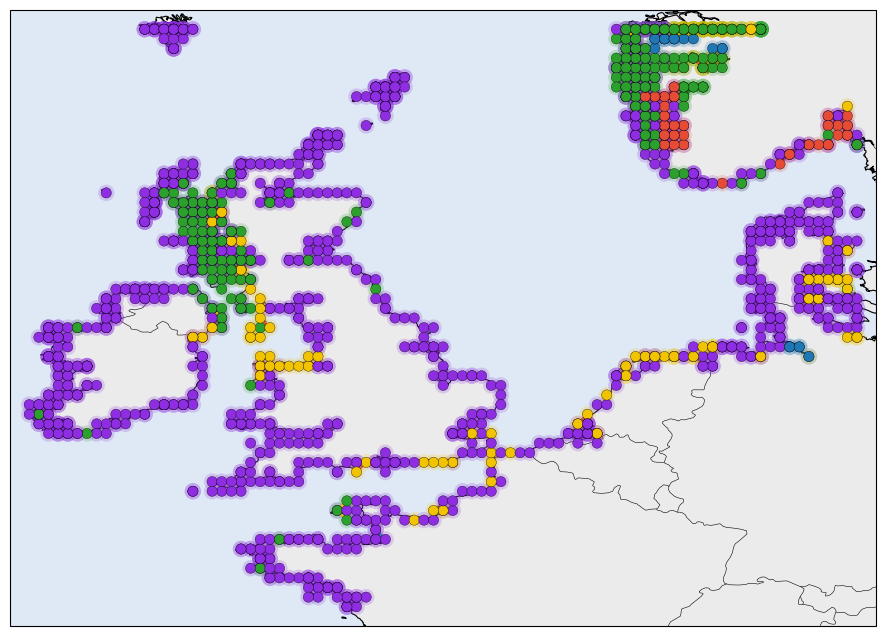

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- setup ---
cluster_col = "pred_cluster"
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()
plot_df[cluster_col] = plot_df[cluster_col].astype(int)

clusters = np.sort(plot_df[cluster_col].unique())
n_clusters = len(clusters)

base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red
]
colors = base_colors[:n_clusters]
cmap = mcolors.ListedColormap(colors)

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="0.92")
ax.add_feature(cfeature.OCEAN, facecolor="#dfe8f5")
ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

ax.set_extent([
    plot_df["lon"].min() - 0.5,
    plot_df["lon"].max() + 0.5,
    plot_df["lat"].min() - 0.5,
    plot_df["lat"].max() + 0.5
], crs=ccrs.PlateCarree())

# --- soft halo underneath ---
ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=140,
    alpha=0.20,
    cmap=cmap,
    linewidth=0,
    transform=ccrs.PlateCarree(),
    zorder=2
)

# --- main points ---
sc = ax.scatter(
    plot_df["lon"],
    plot_df["lat"],
    c=plot_df[cluster_col],
    s=55,
    cmap=cmap,
    edgecolor="k",
    linewidth=0.25,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# --- optional: connect only short local segments within each cluster ---
# This avoids long bogus coast-crossing lines.
for cluster in clusters:
    subset = plot_df.loc[plot_df[cluster_col] == cluster, ["lon", "lat"]].copy()

    coords = subset[["lon", "lat"]].to_numpy()
    if len(coords) < 2:
        continue

    # naive local linking: sort by latitude then longitude as a rough path
    subset = subset.sort_values(["lat", "lon"]).reset_index(drop=True)

    # only draw segment if adjacent points are close enough
    max_dist = 0.4  # tune to your station spacing
    for i in range(len(subset) - 1):
        x1, y1 = subset.loc[i, ["lon", "lat"]]
        x2, y2 = subset.loc[i + 1, ["lon", "lat"]]
        dist = np.hypot(x2 - x1, y2 - y1)

        if dist <= max_dist:
            ax.plot(
                [x1, x2], [y1, y2],
                color=colors[int(cluster)],
                linewidth=2.0,
                alpha=0.8,
                transform=ccrs.PlateCarree(),
                zorder=2.5
            )

# --- legend instead of only colorbar ---
handles = [
    mpatches.Patch(color=colors[i], label=f"Cluster {clusters[i]}")
    for i in range(n_clusters)
]
ax.legend(handles=handles, loc="lower left", title="Regime", frameon=True)

plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03, label=cluster_col)
plt.title("Predicted coastal surge regimes")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# keep only numeric columns
X = X.select_dtypes(include=[np.number]).copy()

# replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# drop columns that are all NaN
X = X.dropna(axis=1, how='all')

# fill remaining NaNs with column means
X = X.fillna(X.mean())
# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
status_cols = [c for c in X_coastline.columns if "status" in c]
# keep only numeric columns
X_coastline = X_coastline.select_dtypes(include=[np.number]).copy()
X_coastline = X_coastline.replace([np.inf, -np.inf], np.nan)
X_coastline = X_coastline.dropna(axis=1, how='all')
X_coastline = X_coastline.fillna(X.mean())

X_coastline_scaled= scaler.transform(X_coastline)
#pred_coastline = rf.predict(X_coastline_scaled)
pred_coastline = rf.predict(X_coastline_scaled)

In [172]:
# Attach predictions to the same rows used for prediction
stats_df_test_pred = stats_df_test.copy()
stats_df_test_pred["pred_cluster"] = pred_coastline

# Pick cluster column to color by
cluster_col = "pred_cluster"   # or use an existing cluster column like "cluster_id"

# Keep only rows that have coordinates and cluster values
plot_df = stats_df_test_pred.dropna(subset=["lat", "lon", cluster_col]).copy()

# Plot

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


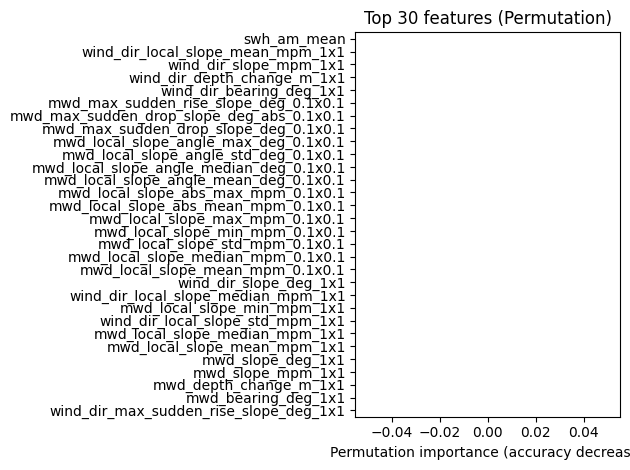

In [217]:
from sklearn.inspection import permutation_importance
# --------------------------------------------------
mdi = pd.Series(rf2.feature_importances_, index=X.columns).sort_values(ascending=False)

perm = permutation_importance(
    rf2,
    X_test,
    y_test,
    n_repeats=30,
    random_state=0,
    n_jobs=-1
)

perm_df = (
    pd.DataFrame({
        "mean": perm.importances_mean,
        "std": perm.importances_std
    }, index=X.columns)
    .sort_values("mean", ascending=False)
)

top_n = 30

plt.figure()
perm_df.head(top_n)["mean"].iloc[::-1].plot(
    kind="barh",
    xerr=perm_df.head(top_n)["std"].iloc[::-1]
)
plt.xlabel("Permutation importance (accuracy decrease)")
plt.title(f"Top {top_n} features (Permutation)")
plt.tight_layout()
plt.show()



Cluster structure is reproducible from independent features.

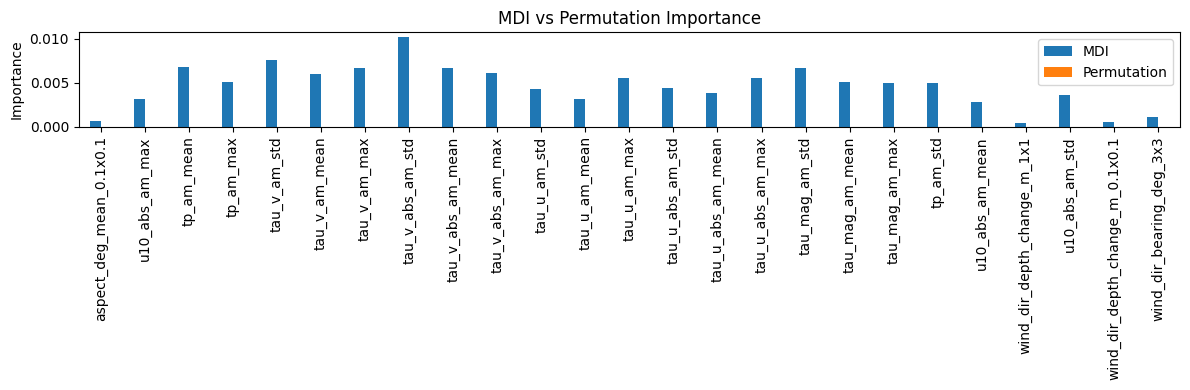

In [220]:
compare = pd.DataFrame({
    "MDI": mdi,
    "Permutation": perm_df["mean"]
}).dropna()

top = compare.sort_values("Permutation", ascending=False).head(25)

top.plot(kind="bar", figsize=(12, 4))
plt.ylabel("Importance")
plt.title("MDI vs Permutation Importance")
plt.tight_layout()
plt.show()


In [222]:
plot_df["cluster"] = plot_df["pred_cluster"]
weathercluster_df = plot_df

In [252]:
top_feat = list(top.reset_index()["index"])

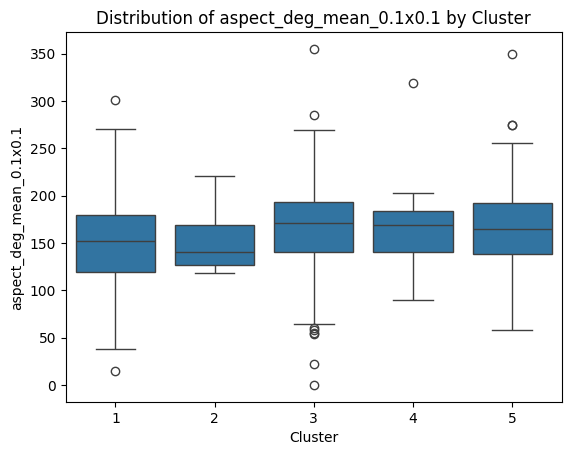

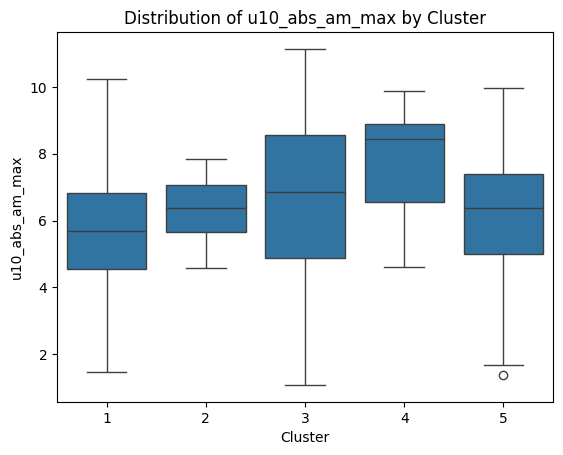

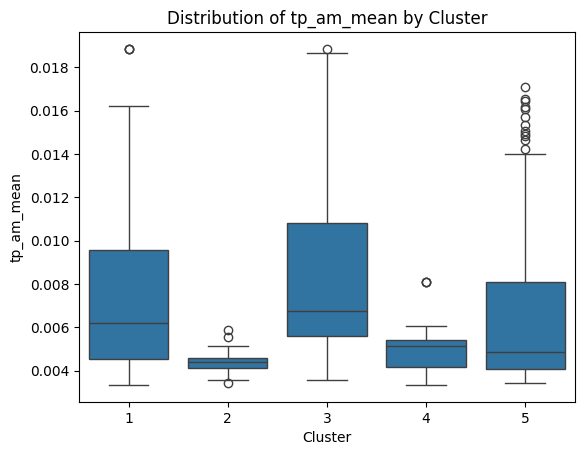

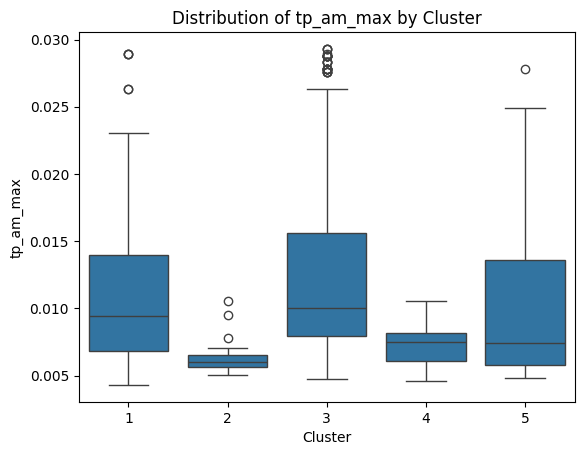

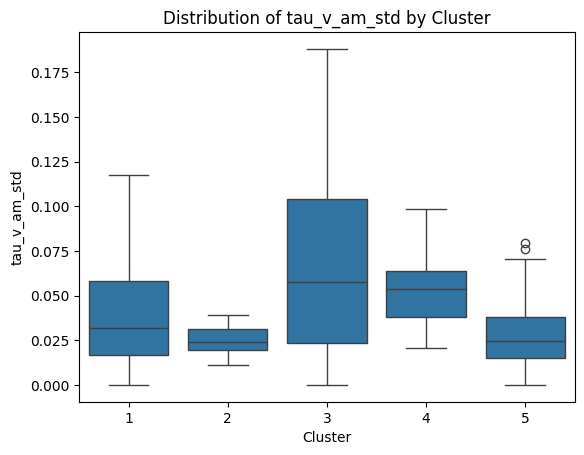

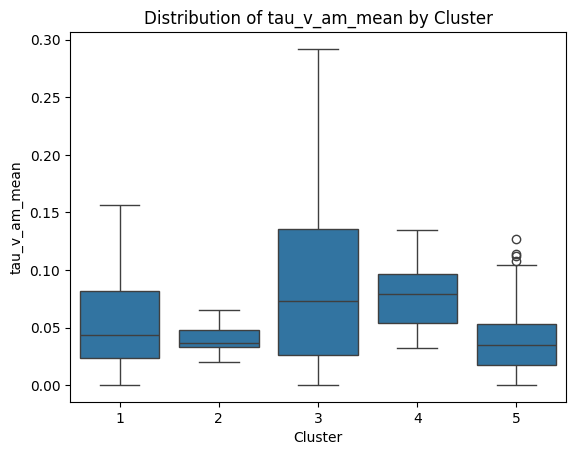

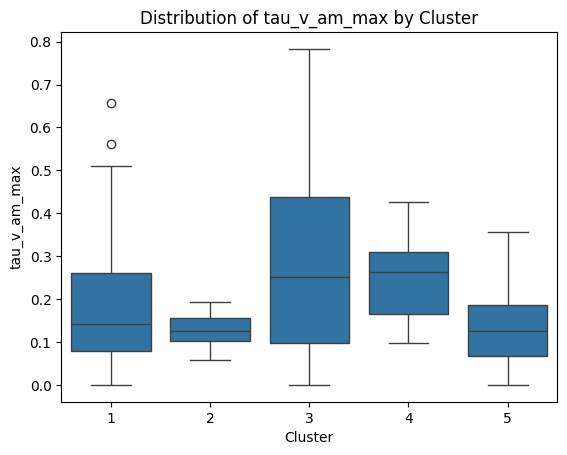

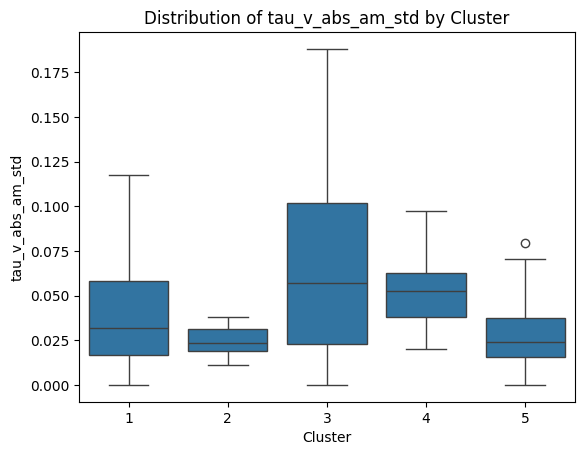

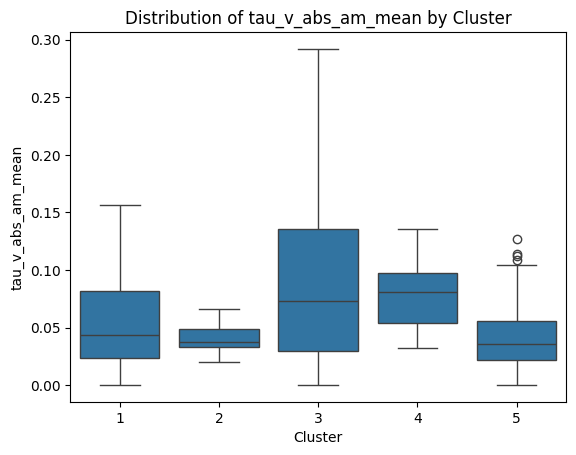

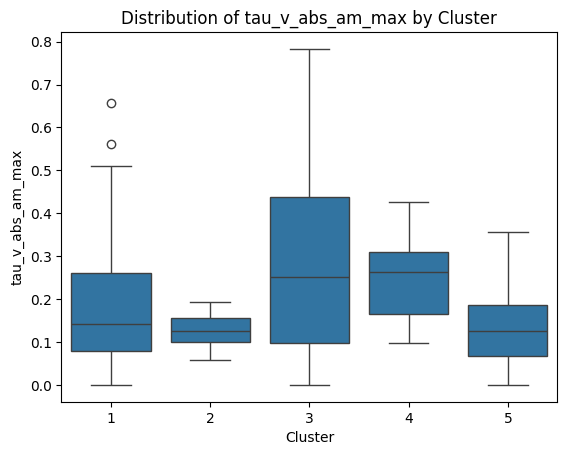

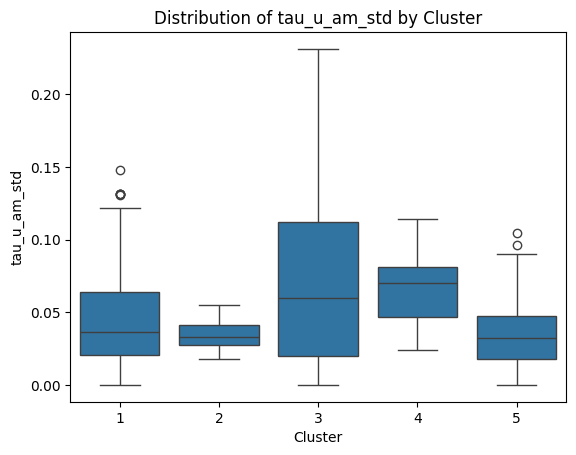

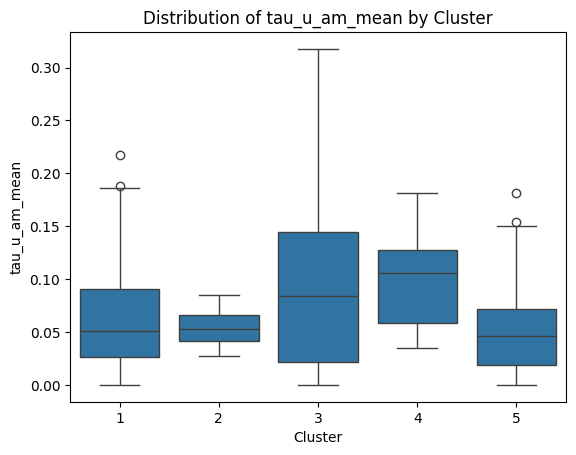

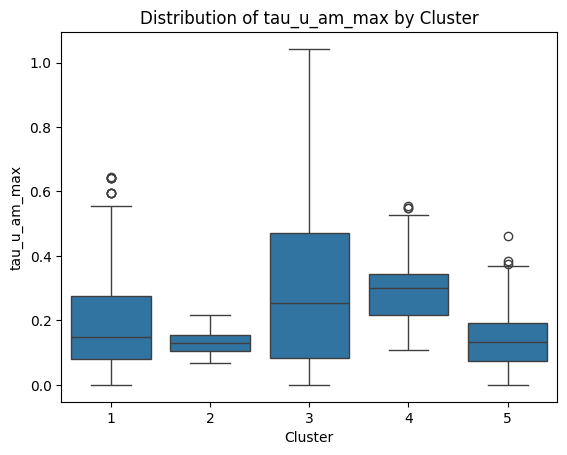

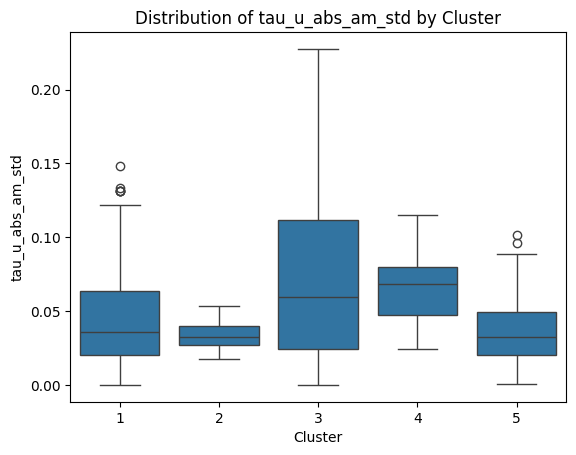

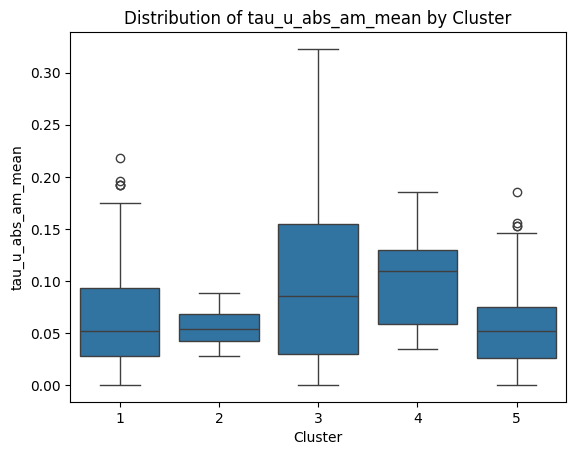

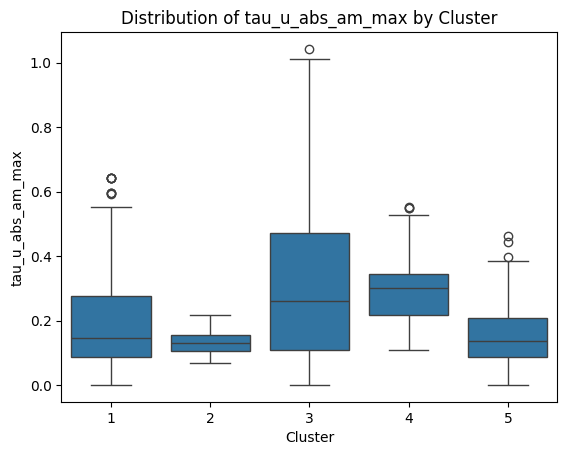

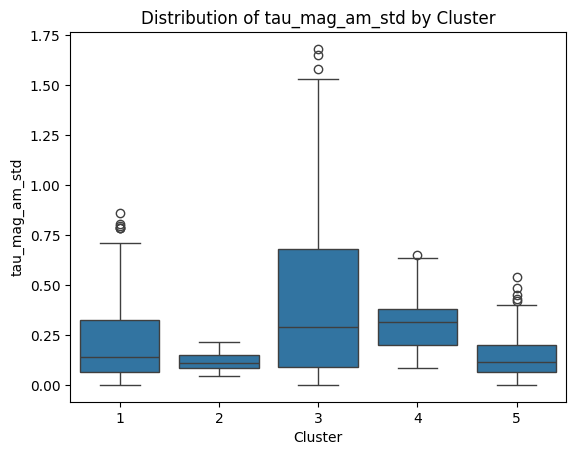

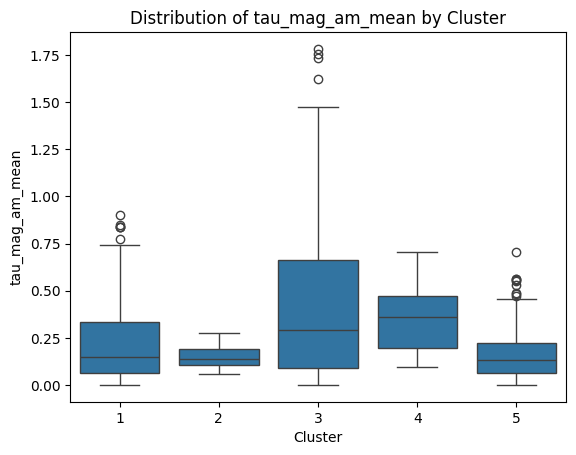

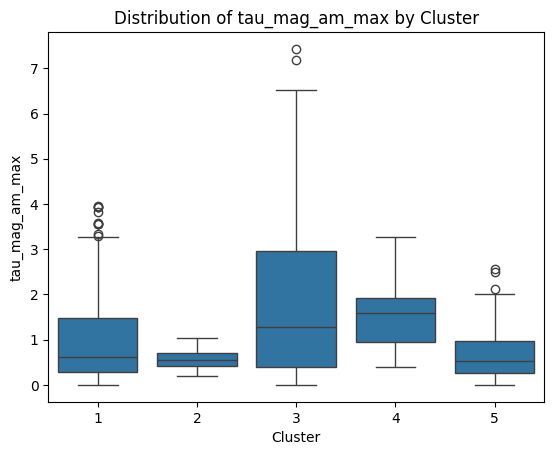

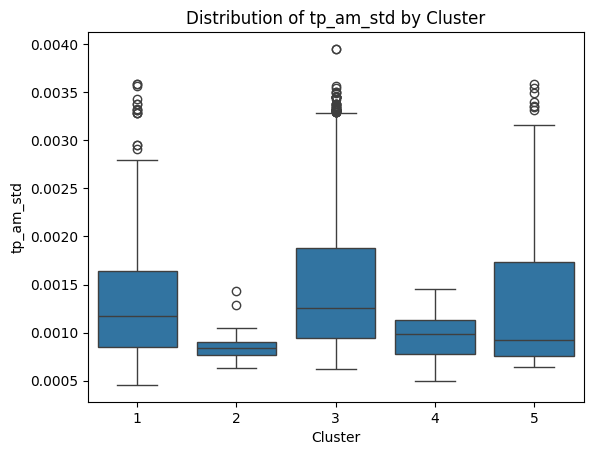

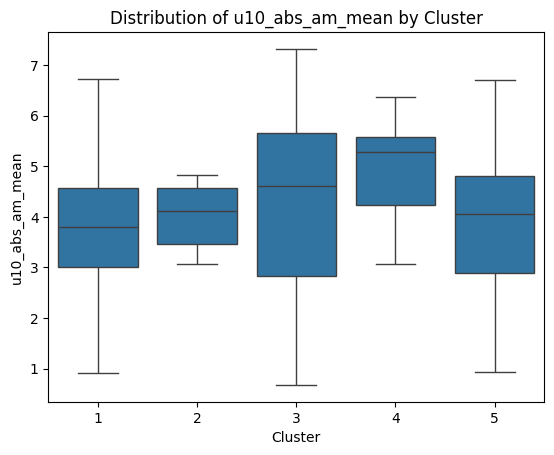

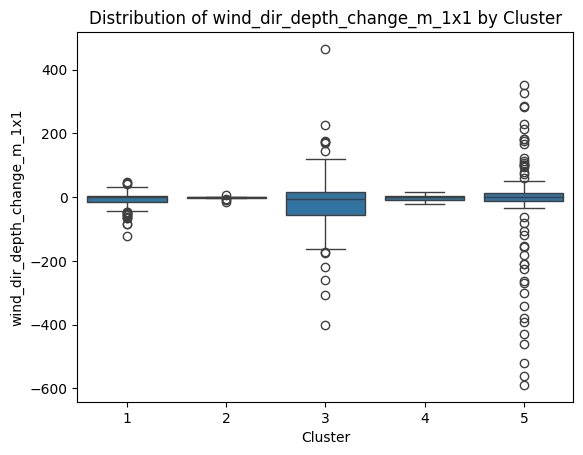

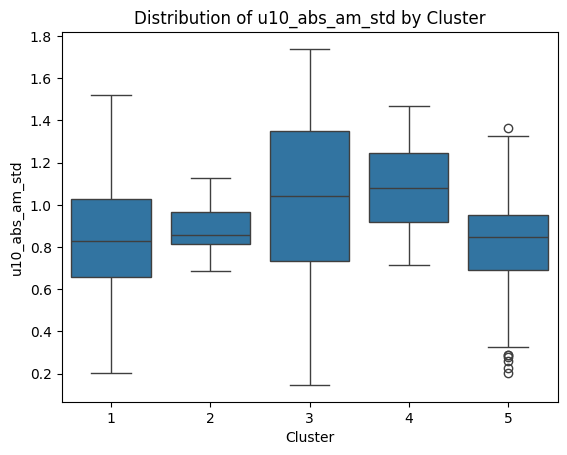

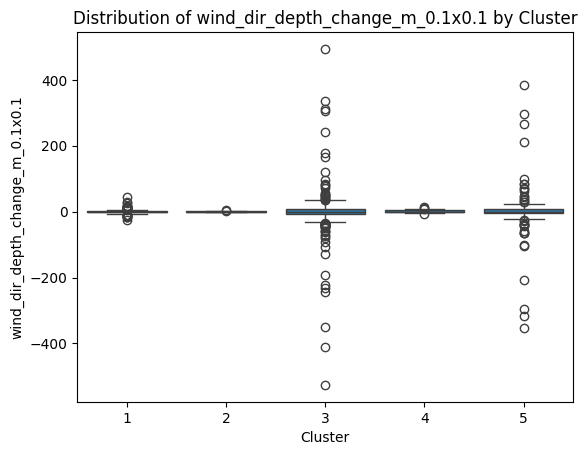

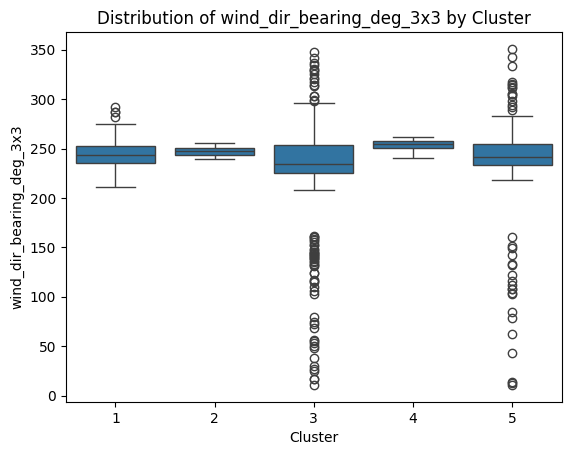

In [254]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loop through each feature and plot
for col in top_feat:
    plt.figure()
    sns.boxplot(data=weathercluster_df, x='cluster', y=col)
    plt.title(f'Distribution of {col} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(col)
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan

    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled =ß np.sqrt(((na - 1)*sa + (nb - 1)*sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled
features = ["aspect_deg_mean_0.1x0.1"]  # add more if you want
clusters = sorted(weathercluster_df["cluster"].unique())

rows = []
for feat in features:
    for c1, c2 in combinations(clusters, 2):
        a = weathercluster_df.loc[weathercluster_df.cluster == c1, feat]
        b = weathercluster_df.loc[weathercluster_df.cluster == c2, feat]
        d = cohens_d(a, b)
        rows.append({
            "feature": feat,
            "cluster_1": c1,
            "cluster_2": c2,
            "cohens_d": d,
            "abs_d": abs(d)
        })

d_all = (
    pd.DataFrame(rows)
      .sort_values(["feature", "abs_d"], ascending=[True, False])
)

d_all


,feature,cluster_1,cluster_2,cohens_d,abs_d
4,aspect_deg_mean_0.1x0.1,2,3,-0.379171,0.379171
5,aspect_deg_mean_0.1x0.1,2,4,-0.378763,0.378763
6,aspect_deg_mean_0.1x0.1,2,5,-0.347837,0.347837
1,aspect_deg_mean_0.1x0.1,1,3,-0.328750,0.328750
3,aspect_deg_mean_0.1x0.1,1,5,-0.294269,0.294269
2,aspect_deg_mean_0.1x0.1,1,4,-0.252175,0.252175
7,aspect_deg_mean_0.1x0.1,3,4,0.079853,0.079853
9,aspect_deg_mean_0.1x0.1,4,5,-0.057387,0.057387
0,aspect_deg_mean_0.1x0.1,1,2,0.034373,0.034373
8,aspect_deg_mean_0.1x0.1,3,5,0.020988,0.020988


# unequal group sizes
mean / sqrt (std1^2+std2^2)

In [228]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = model_df.copy()[[c for c in top if c in model_df.columns]]

# drop obvious non-predictors if desired
drop_cols = ["geometry"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

cols = df.columns
n_cols = len(cols)

n_per_row = 3
n_rows = int(np.ceil(n_cols / n_per_row))

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(12, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):

    ax = axes[i]

    if pd.api.types.is_numeric_dtype(df[col]):
        ax.hist(df[col].dropna(), bins=30)
        ax.set_ylabel("count")
    else:
        df[col].value_counts().plot(kind="bar", ax=ax)
        ax.set_ylabel("count")

    ax.set_title(col, fontsize=9)
    ax.tick_params(axis="x", labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

# remove unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

ValueError: Number of rows must be a positive integer, not 0

<Figure size 1200x0 with 0 Axes>

In [ ]:
weathercluster_df

Index(['station', 'swh_am_mean', 'swh_am_std', 'swh_am_max', 'mwp_am_mean',
       'mwp_am_std', 'mwp_am_max', 'wsk_am_mean', 'wsk_am_std', 'wsk_am_max',
       ...
       'mwd_max_sudden_rise_slope_deg_10x10',
       'mwd_corridor_depth_mean_m_10x10', 'mwd_corridor_depth_std_m_10x10',
       'mwd_corridor_depth_min_m_10x10', 'mwd_corridor_depth_max_m_10x10',
       'mwd_status_10x10', 'wind_status_10x10', 'wave_status_10x10',
       'pred_cluster', 'cluster'],
      dtype='object', length=468)

In [230]:
top

,MDI,Permutation
aspect_deg_mean_0.1x0.1,0.000620,0.0
u10_abs_am_max,0.003125,0.0
tp_am_mean,0.006817,0.0
tp_am_max,0.005111,0.0
tau_v_am_std,0.007595,0.0
tau_v_am_mean,0.005946,0.0
tau_v_am_max,0.006678,0.0
tau_v_abs_am_std,0.010206,0.0
tau_v_abs_am_mean,0.006619,0.0
tau_v_abs_am_max,0.006038,0.0


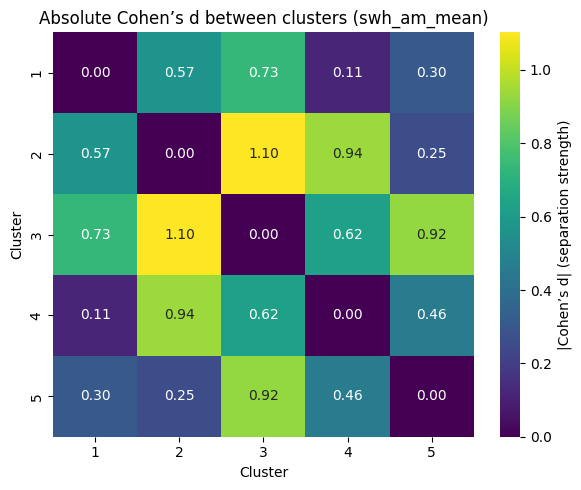

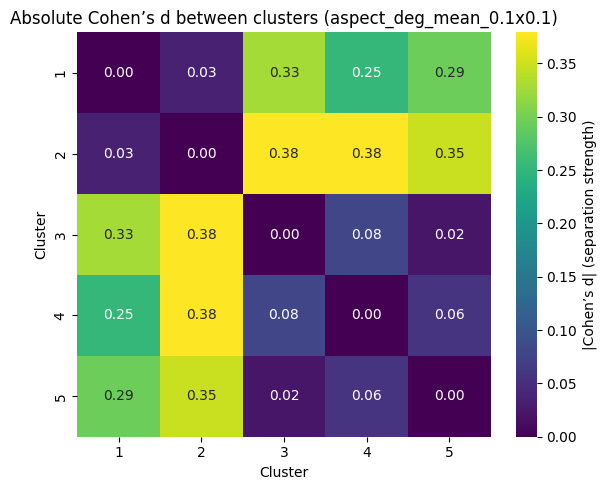

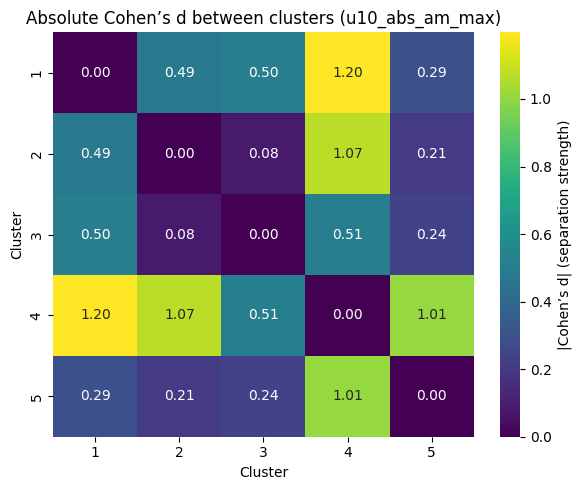

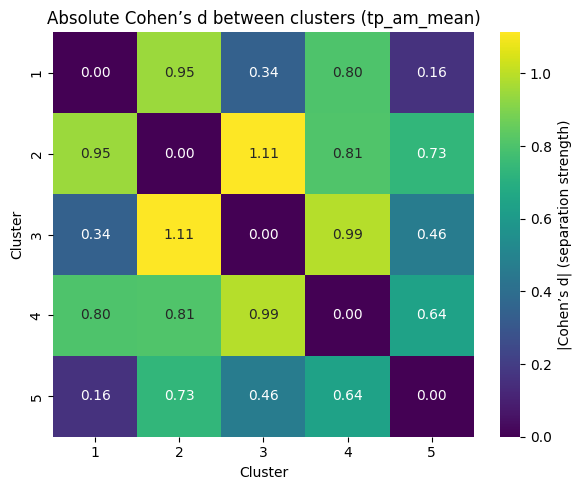

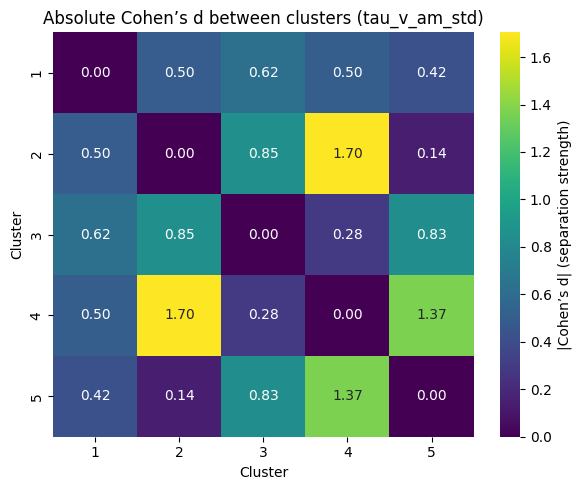

In [231]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def cohens_d(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]

    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan

    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na - 1)*sa + (nb - 1)*sb) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled


def cohens_d_abs_matrix(df, feature):
    clusters = sorted(df["cluster"].unique())
    mat = pd.DataFrame(index=clusters, columns=clusters, dtype=float)

    for i in clusters:
        for j in clusters:
            if i == j:
                mat.loc[i, j] = 0.0
            else:
                a = df.loc[df.cluster == i, feature]
                b = df.loc[df.cluster == j, feature]
                mat.loc[i, j] = abs(cohens_d(a, b))
    return mat


features = ['swh_am_mean', 'aspect_deg_mean_0.1x0.1', 'u10_abs_am_max', 'tp_am_mean', 'tau_v_am_std']

for feat in features:
    mat = cohens_d_abs_matrix(weathercluster_df, feat)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        mat,
        cmap="viridis",          # sequential colormap
        vmin=0,
        vmax=np.nanmax(mat.values),
        annot=True,
        fmt=".2f",
        cbar_kws={"label": "|Cohen’s d| (separation strength)"}
    )
    plt.title(f"Absolute Cohen’s d between clusters ({feat})")
    plt.xlabel("Cluster")
    plt.ylabel("Cluster")
    plt.tight_layout()
    plt.show()

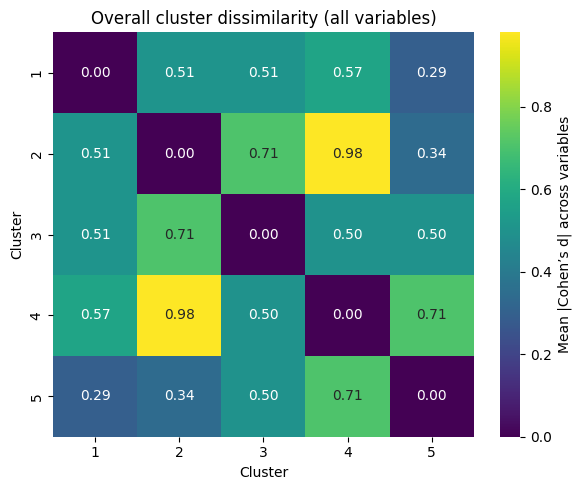

In [232]:
import numpy as np
import pandas as pd

clusters = sorted(weathercluster_df.cluster.unique())

# initialize accumulator
overall = pd.DataFrame(
    0.0, index=clusters, columns=clusters
)

for feat in features:
    mat = cohens_d_abs_matrix(weathercluster_df, feat)
    overall += mat

overall /= len(features)
plt.figure(figsize=(6, 5))
sns.heatmap(
    overall,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Mean |Cohen’s d| across variables"}
)
plt.title("Overall cluster dissimilarity (all variables)")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [233]:
records = []

for i in clusters:
    for j in clusters:
        if i >= j:
            continue

        ds = {}
        for feat in features:
            mat = cohens_d_abs_matrix(weathercluster_df, feat)
            ds[feat] = mat.loc[i, j]

        top_feat = max(ds, key=ds.get)

        records.append({
            "cluster_i": i,
            "cluster_j": j,
            "mean_abs_d": np.mean(list(ds.values())),
            "max_abs_d": ds[top_feat],
            "driving_variable": top_feat
        })

pairwise_summary = pd.DataFrame(records)


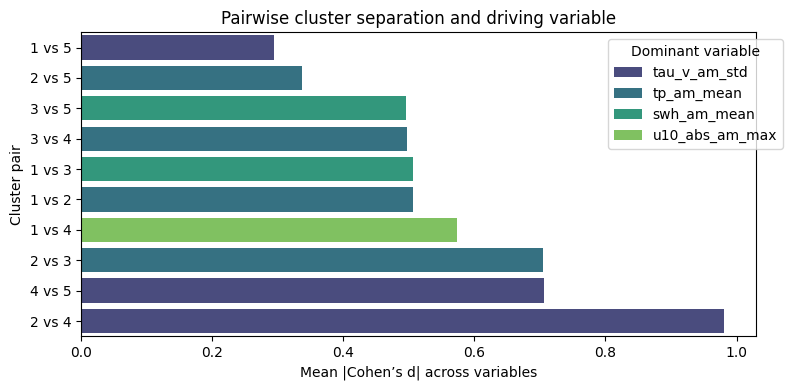

In [234]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=pairwise_summary.sort_values("mean_abs_d"),
    x="mean_abs_d",
    y=pairwise_summary.sort_values("mean_abs_d")
        .apply(lambda r: f"{r.cluster_i} vs {r.cluster_j}", axis=1),
    hue="driving_variable",
    dodge=False,
    palette="viridis"
)

plt.xlabel("Mean |Cohen’s d| across variables")
plt.ylabel("Cluster pair")
plt.title("Pairwise cluster separation and driving variable")
plt.legend(title="Dominant variable", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


In [235]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def mean_abs_cohens_d_vs_others(df, feature, cluster_id):
    """Mean |Cohen's d| of cluster vs all other clusters"""
    target = df.loc[df.cluster == cluster_id, feature]
    ds = []

    for other in df.cluster.unique():
        if other == cluster_id:
            continue
        comp = df.loc[df.cluster == other, feature]
        d = cohens_d(target, comp)
        if np.isfinite(d):
            ds.append(abs(d))

    return np.mean(ds) if ds else np.nan


In [236]:

features = ['swh_am_mean', 'aspect_deg_mean_0.1x0.1', 'u10_abs_am_max', 'tp_am_mean', 'tau_v_am_std']
clusters = sorted(weathercluster_df.cluster.unique())

rows = []

for c in clusters:
    for f in features:
        rows.append({
            "cluster": c,
            "feature": f,
            "mean_abs_d": mean_abs_cohens_d_vs_others(
                weathercluster_df, f, c
            )
        })

sep_df = pd.DataFrame(rows)

top2_df = (
    sep_df
    .sort_values(["cluster", "mean_abs_d"], ascending=[True, False])
    .groupby("cluster")
    .head(2)
)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_66251/766518768.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


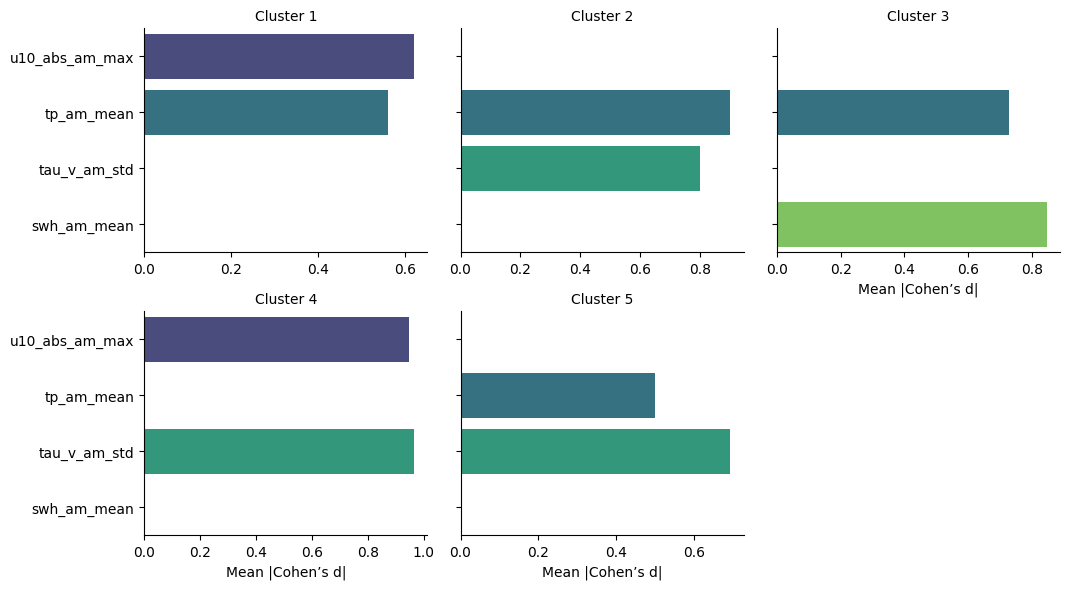

In [237]:
g = sns.catplot(
    data=top2_df,
    kind="bar",
    x="mean_abs_d",
    y="feature",
    col="cluster",
    col_wrap=3,
    sharex=False,
    height=3,
    aspect=1.2,
    palette="viridis"
)

g.set_titles("Cluster {col_name}")
g.set_xlabels("Mean |Cohen’s d|")
g.set_ylabels("")
plt.tight_layout()
plt.show()


In [238]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def cohens_d_cluster_vs_rest(df, feature, cluster_id):
    a = df.loc[df.cluster == cluster_id, feature]
    b = df.loc[df.cluster != cluster_id, feature]
    return abs(cohens_d(a, b))


In [239]:

features = ['swh_am_mean', 'aspect_deg_mean_0.1x0.1', 'u10_abs_am_max', 'tp_am_mean', 'tau_v_am_std']
clusters = sorted(weathercluster_df.cluster.unique())

rows = []

for c in clusters:
    for f in features:
        rows.append({
            "cluster": c,
            "feature": f,
            "abs_d": cohens_d_cluster_vs_rest(
                weathercluster_df, f, c
            )
        })

sep_df = pd.DataFrame(rows)


In [240]:
top2_df = (
    sep_df
    .sort_values(["cluster", "abs_d"], ascending=[True, False])
    .groupby("cluster")
    .head(2)
)


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_66251/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


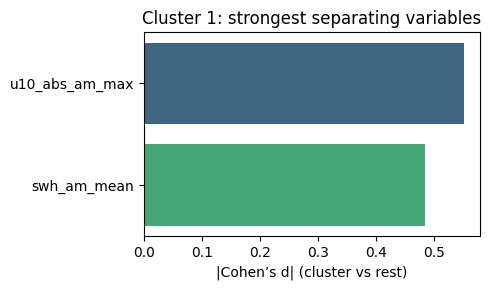

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_66251/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


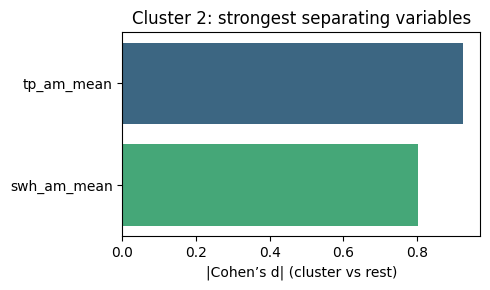

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_66251/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


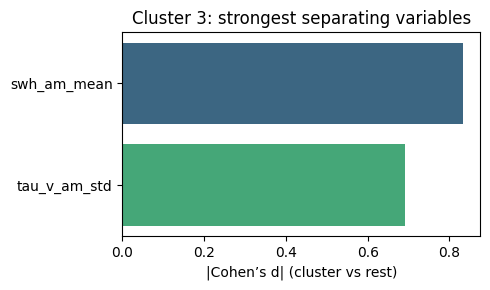

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_66251/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


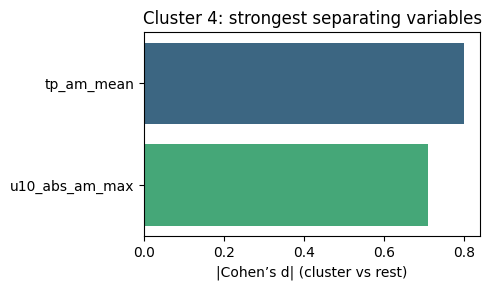

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_66251/195459939.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


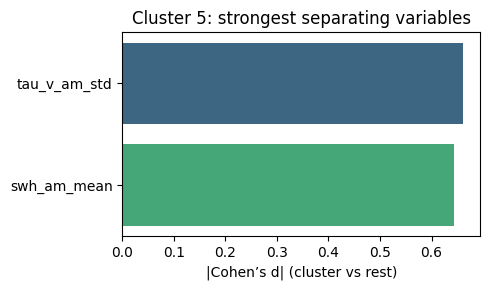

In [241]:
for c in clusters:
    sub = top2_df[top2_df.cluster == c]

    plt.figure(figsize=(5, 3))
    sns.barplot(
        data=sub,
        x="abs_d",
        y="feature",
        palette="viridis"
    )

    plt.title(f"Cluster {c}: strongest separating variables")
    plt.xlabel("|Cohen’s d| (cluster vs rest)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


Interpretation

|d| ≈ 0.2 → small

|d| ≈ 0.5 → medium

|d| ≥ 0.8 → large separation

|d| ≥ 1.2 → very strong

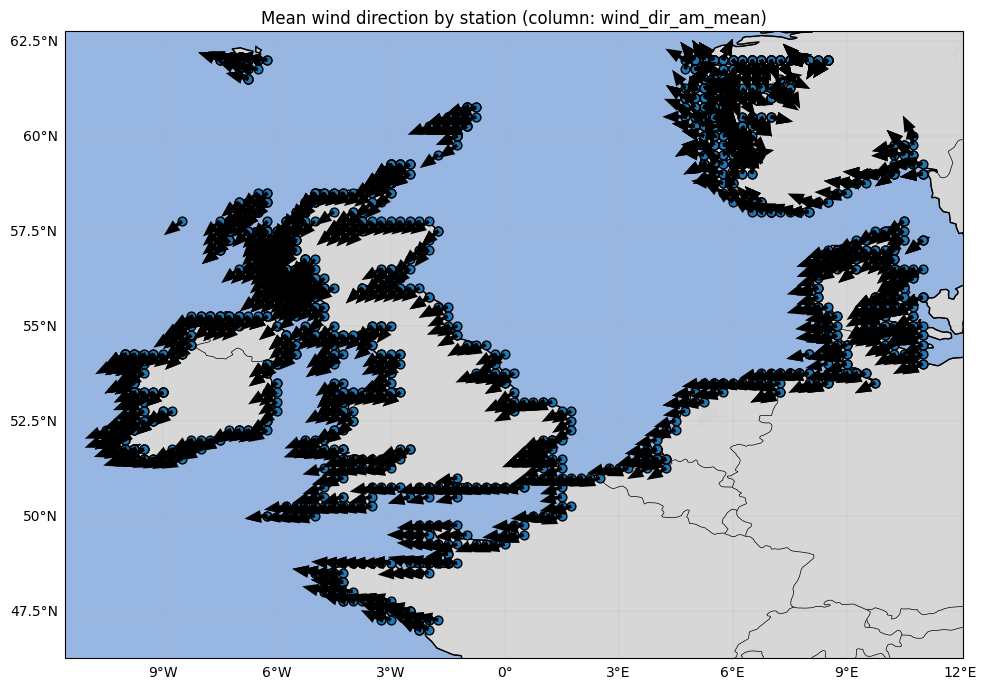

In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---- Inputs you may need to adjust ----
df = weathercluster_df.copy()

# Required columns: station + lat/lon
req = {"station", "lat", "lon"}
assert req.issubset(df.columns), f"weather_cluster_df must include {req}"

# Try to auto-detect a wind-direction column (degrees)
cand_cols = [c for c in df.columns if any(s in c.lower() for s in ["wind_dir", "winddirection", "wd", "wdir", "dir"])]
if not cand_cols:
    raise ValueError("Couldn't auto-detect wind direction column. Set wind_dir_col manually.")
wind_dir_col = cand_cols[0]   # <-- or set manually, e.g. wind_dir_col = "wind_dir"

# If your wind direction is in radians, convert it before proceeding.
# df[wind_dir_col] = np.rad2deg(df[wind_dir_col])

# ---- Clean numeric ----
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df[wind_dir_col] = pd.to_numeric(df[wind_dir_col], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["station","lon","lat",wind_dir_col])

# ---- Circular mean per station (degrees) ----
# Assumption: wind direction is METEOROLOGICAL degrees (0=N, 90=E) and indicates "FROM" direction.
# We'll plot arrows pointing TO where wind is going (common for vector arrows).
theta_from = df[wind_dir_col].values % 360.0
theta_to = (theta_from + 180.0) % 360.0

# Circular mean: mean of unit vectors (using "TO" direction)
rad = np.deg2rad(theta_to)
df["_sin"] = np.sin(rad)
df["_cos"] = np.cos(rad)

station_mean = (
    df.groupby("station", as_index=False)
      .agg(lon=("lon","mean"),
           lat=("lat","mean"),
           sin_mean=("_sin","mean"),
           cos_mean=("_cos","mean"))
)

# Mean direction (TO), in degrees meteorological
mean_rad = np.arctan2(station_mean["sin_mean"].values, station_mean["cos_mean"].values)
mean_deg_to = (np.rad2deg(mean_rad) + 360.0) % 360.0
station_mean["mean_wind_dir_to_deg"] = mean_deg_to

# Convert MET degrees (0=N, clockwise) -> plotting components (x=lon/east, y=lat/north)
# MET "TO" degrees: 0=N means arrow points +y. 90=E means +x.
theta = np.deg2rad(station_mean["mean_wind_dir_to_deg"].values)
u = np.sin(theta)   # east component
v = np.cos(theta)   # north component

# ---- Map ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

lon_min, lon_max = station_mean["lon"].min(), station_mean["lon"].max()
lat_min, lat_max = station_mean["lat"].min(), station_mean["lat"].max()
pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent([lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat], crs=proj)

ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", alpha=0.9, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Plot station points
ax.scatter(station_mean["lon"], station_mean["lat"], s=40, transform=proj, zorder=10, edgecolors="k")

# Quiver: constant-length arrows; scale_units='xy' keeps units consistent
# Increase/decrease 'arrow_len' to taste.
arrow_len = 0.6
ax.quiver(
    station_mean["lon"].values,
    station_mean["lat"].values,
    u * arrow_len,
    v * arrow_len,
    transform=proj,
    zorder=20,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    headwidth=3.5,
    headlength=4.5
)

ax.set_title(f"Mean wind direction by station (column: {wind_dir_col})")
plt.tight_layout()
plt.show()


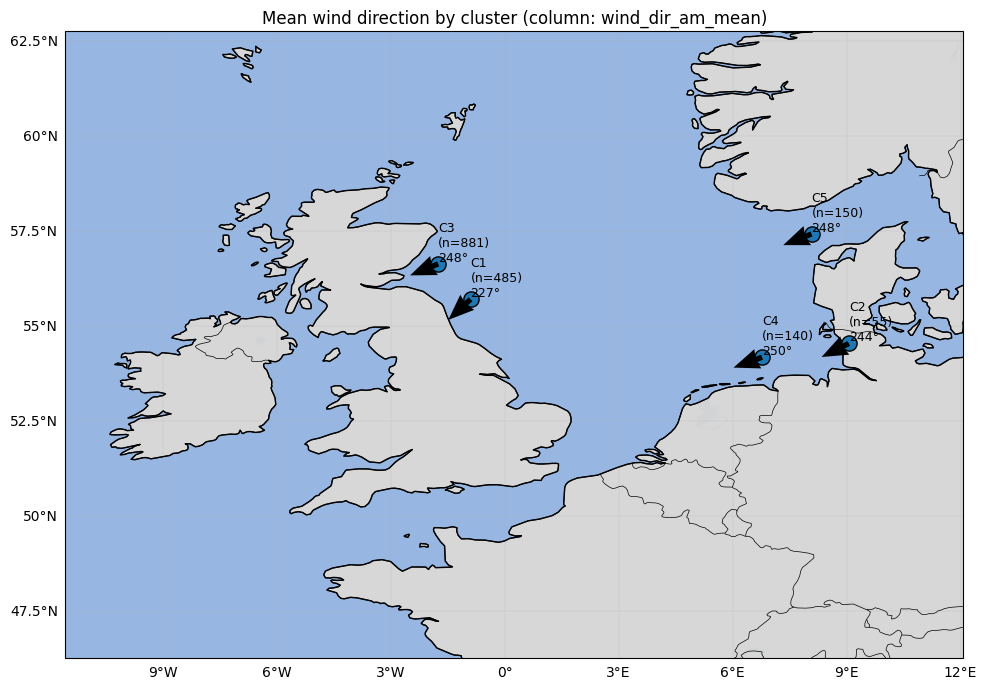

   cluster    n        lat       lon  mean_wind_dir_to_deg
0        1  485  55.695876 -0.899485            227.196327
1        2   55  54.531818  9.059091            243.597864
2        3  881  56.628547 -1.751135            247.666539
3        4  140  54.169643  6.775000            250.026577
4        5  150  57.415000  8.076667            248.487018


In [243]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

df = weathercluster_df.copy()

# --- Required columns ---
req = {"cluster", "lat", "lon"}
assert req.issubset(df.columns), f"weathercluster_df must include {req}"

# --- Auto-detect wind direction column (degrees) ---
cand_cols = [c for c in df.columns if any(s in c.lower() for s in ["wind_dir", "winddirection", "wd", "wdir", "dir"])]
if not cand_cols:
    raise ValueError("Couldn't auto-detect wind direction column. Set wind_dir_col manually.")
wind_dir_col = cand_cols[0]  # or set explicitly

# --- Clean numeric ---
for c in ["lon", "lat", "cluster", wind_dir_col]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lon", "lat", "cluster", wind_dir_col])

# --- Circular mean per cluster (meteorological degrees; assumed 'FROM') ---
theta_from = df[wind_dir_col].values % 360.0
theta_to = (theta_from + 180.0) % 360.0  # plot arrows pointing where wind goes

rad = np.deg2rad(theta_to)
df["_sin"] = np.sin(rad)
df["_cos"] = np.cos(rad)

cluster_mean = (
    df.groupby("cluster", as_index=False)
      .agg(lon=("lon", "mean"),
           lat=("lat", "mean"),
           sin_mean=("_sin", "mean"),
           cos_mean=("_cos", "mean"),
           n=("cluster", "size"))
)

mean_rad = np.arctan2(cluster_mean["sin_mean"].values, cluster_mean["cos_mean"].values)
mean_deg_to = (np.rad2deg(mean_rad) + 360.0) % 360.0
cluster_mean["mean_wind_dir_to_deg"] = mean_deg_to

# Components for plotting (MET degrees: 0=N, 90=E)
theta = np.deg2rad(cluster_mean["mean_wind_dir_to_deg"].values)
u = np.sin(theta)   # east
v = np.cos(theta)   # north

# --- Map ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

lon_min, lon_max = df["lon"].min(), df["lon"].max()
lat_min, lat_max = df["lat"].min(), df["lat"].max()
pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent([lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat], crs=proj)

ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="black", alpha=0.9, zorder=2)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Cluster centroid points
ax.scatter(cluster_mean["lon"], cluster_mean["lat"], s=120, transform=proj, zorder=10, edgecolors="k")

# Cluster mean direction arrows
arrow_len = 0.8
ax.quiver(
    cluster_mean["lon"].values,
    cluster_mean["lat"].values,
    u * arrow_len,
    v * arrow_len,
    transform=proj,
    zorder=20,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.006,
    headwidth=3.8,
    headlength=4.8
)

# Label clusters (optionally include n)
for _, r in cluster_mean.iterrows():
    ax.text(
        r["lon"], r["lat"],
        f"C{int(r['cluster'])}\n(n={int(r['n'])})\n{r['mean_wind_dir_to_deg']:.0f}°",
        transform=proj,
        ha="left", va="bottom",
        fontsize=9,
        zorder=30
    )

ax.set_title(f"Mean wind direction by cluster (column: {wind_dir_col})")
plt.tight_layout()
plt.show()

# Also print the table for inspection
display_cols = ["cluster", "n", "lat", "lon", "mean_wind_dir_to_deg"]
print(cluster_mean[display_cols].sort_values("cluster"))


In [244]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cluster_means = weathercluster_df.groupby("cluster")[top].mean()

# Column-wise min–max for coloring
color_data = (
    cluster_means - cluster_means.min()
) / (
    cluster_means.max() - cluster_means.min()
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    color_data,
    annot=cluster_means.round(2),  # <-- actual values
    fmt="",
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Relative position within variable"}
)
plt.title("Cluster Centroids (actual values, min–max color-scaled per variable)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


TypeError: unhashable type: 'DataFrame'

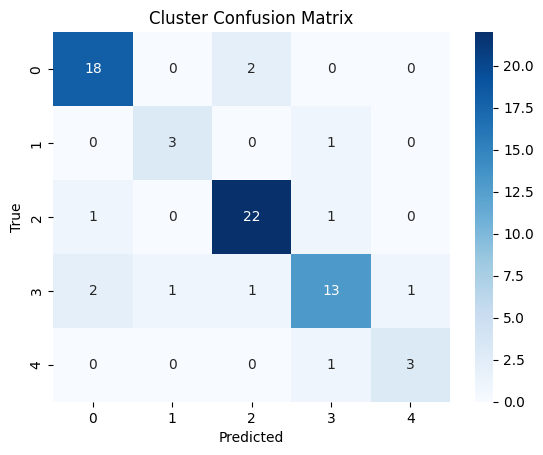

In [245]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Cluster Confusion Matrix")
plt.show()



In [246]:
cluster_means_minmax = (
    cluster_means - cluster_means.min()
) / (
    cluster_means.max() - cluster_means.min()
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    cluster_means_minmax,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)
plt.title("Cluster Centroids (min–max per variable)")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


NameError: name 'cluster_means' is not defined